# Proyecto Integrador Módulo 4 – Machine Learning
## Avance 1: EDA y Regresión Logística
**FinanceGuard - Predicción de Churn Bancario**

---

---

## 1. Contexto y objetivo del proyecto

El churn bancario representa la pérdida de clientes que deciden abandonar una institución financiera, lo que impacta directamente en los ingresos y en los costos de adquisición de nuevos clientes. En el contexto de un banco digital como FinanceGuard, identificar de manera temprana a los clientes con mayor riesgo de abandono es clave para implementar estrategias de retención más eficientes.

El objetivo de este proyecto es desarrollar un modelo de Machine Learning que estime la probabilidad de churn de cada cliente. Este modelo no toma decisiones de negocio de forma autónoma, sino que funciona como una herramienta de priorización, permitiendo al equipo de retención focalizar sus esfuerzos en aquellos clientes con mayor riesgo de abandono.

A lo largo de este notebook se realiza un análisis exploratorio de los datos, la preparación de las variables y la implementación de un modelo de regresión logística, evaluando su desempeño y la interpretabilidad de sus resultados.

### 1.1. Criterio de éxito del modelo

Dado que el churn es un problema inherentemente desbalanceado, el desempeño del modelo no puede evaluarse únicamente mediante métricas globales como la accuracy. En este contexto, resulta más relevante la capacidad del modelo para identificar correctamente a los clientes con alto riesgo de abandono, incluso si esto implica un mayor número de falsos positivos.

Por este motivo, métricas como Recall, Precision, F1-Score y AUC-ROC serán clave para evaluar el desempeño del modelo. En particular, se priorizará el Recall de la clase positiva (clientes que abandonan), ya que no detectar a un cliente en riesgo puede resultar más costoso para el negocio que contactar a un cliente que finalmente no abandone

## 2. importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier

## 3. Carga del dataset

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


El dataset contiene información de 10.000 clientes de un banco digital, junto con variables demográficas, financieras y de comportamiento. Cada fila representa un cliente, y la variable objetivo indica si el cliente abandonó el banco.

In [3]:
#Forma del dataset
df.shape

(10000, 14)

## 4. Exploración inicial de datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### 4.1 Descripción general del dataset

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


A partir de la exploración inicial se observa que el dataset cuenta con 10.000 registros y variables de distinto tipo: numéricas, categóricas y una variable objetivo binaria = `Exited`. Este primer análisis permite identificar qué variables requerirán tratamiento adicional en etapas posteriores, como codificación o escalamiento.

### 4.2 Eliminación de columnas irrelevantes 

In [6]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

Estas variables no solo no aportan información predictiva, sino que además podrían inducir sobreajuste si el modelo memoriza identificadores.

### 4.3 Distribución de la variable objetivo

In [7]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [8]:
# Conteo de valores en la columna 'Exited' (variable objetivo)
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
# Conteo normalizado
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [10]:
# Mismo conteo pero en porcentaje
df['Exited'].value_counts()*100/len(df)

Exited
0    79.63
1    20.37
Name: count, dtype: float64

### 4.4 Investigación del Churn Bancario

#### ¿Qué es el Churn Bancario?

El **churn bancario** (o tasa de abandono) se refiere al porcentaje de clientes que dejan de utilizar los servicios de una entidad financiera en un período determinado. En el contexto de FinanceGuard, un cliente se considera "churned" cuando cierra su cuenta o deja de operar con el banco.

El churn puede manifestarse de diferentes formas:
- **Churn voluntario**: El cliente decide activamente cerrar su cuenta o cambiar de banco
- **Churn involuntario**: La cuenta se cierra por inactividad prolongada o incumplimiento de políticas

#### Importancia del Problema

La predicción y prevención del churn es crítica para la industria bancaria por las siguientes razones:

**1. Impacto Económico Directo**
- Adquirir un nuevo cliente cuesta entre 5 y 25 veces más que retener uno existente
- La pérdida de un cliente representa no solo la pérdida de ingresos actuales, sino también del valor de vida del cliente (Customer Lifetime Value)
- En el caso de FinanceGuard, con 10,000 clientes y un churn del 20% anual, se pierden 2,000 clientes cada año

**2. Valor Estratégico**
- Los clientes leales tienden a contratar más productos con el tiempo (cross-selling)
- Clientes satisfechos generan recomendaciones y nuevos clientes (efecto de red)
- La retención mejora la estabilidad financiera del banco a largo plazo

**3. Ventaja Competitiva**
- Identificar clientes en riesgo permite implementar estrategias de retención personalizadas
- Reducir el churn del 20% al 15% (objetivo de FinanceGuard) significaría retener 500 clientes adicionales anualmente
- Un modelo predictivo efectivo permite actuar de manera proactiva, no reactiva

**4. Optimización de Recursos**
- Focalizar esfuerzos de retención en clientes con alta probabilidad de abandono
- Asignar recursos de manera más eficiente al equipo de retención
- Diseñar campañas y beneficios dirigidos a los segmentos más vulnerables

### 4.5 Visualización de la distribución de la variable objetivo

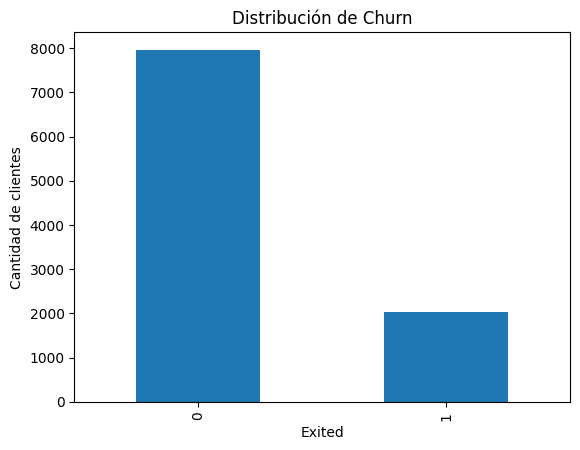

In [11]:
df['Exited'].value_counts().plot(kind='bar')
plt.title("Distribución de Churn")
plt.xlabel("Exited")
plt.ylabel("Cantidad de clientes")
plt.show()

La variable `Exited` presenta un desbalance típico en problemas de churn:

- **Clientes activos (0):** 79.63%  
- **Clientes que abandonaron (1):** 20.37%  

Este resultado confirma que el dataset está desbalanceado, con una mayoría de clientes que permanecen activos.  
Por este motivo, métricas como **Recall**, **Precision**, **F1-Score** y **AUC-ROC** serán más adecuadas que la accuracy para evaluar el desempeño del modelo, ya que permiten medir la capacidad de identificar correctamente a los clientes en riesgo de abandono.

### 4.6 Análisis exploratorio de la variable `gender`

In [12]:
df['Gender'].value_counts(normalize=True)

Gender
Male      0.5457
Female    0.4543
Name: proportion, dtype: float64

La variable `Gender` muestra una distribución relativamente balanceada entre hombres y mujeres:

- **Hombres:** 54.57%  
- **Mujeres:** 45.43%  

Este resultado indica que no existe un sesgo fuerte hacia un género en particular dentro de la base de clientes. Sin embargo, el género podría influir en el comportamiento de churn y será evaluado en el modelo.

En cuanto a la variable `Geography`, se analizará su distribución en el siguiente paso para identificar posibles diferencias en el abandono según país de residencia.

---


### 4.7 Análisis exploratorio de la variable `geography`

In [13]:
df['Geography'].value_counts(normalize=True)

Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

La variable `Geography` refleja la procedencia de los clientes:

- **Francia:** 50.14%  
- **Alemania:** 25.09%  
- **España:** 24.77%  

La mayoría de los clientes provienen de Francia, mientras que Alemania y España tienen proporciones similares pero menores.  
Esta distribución sugiere que la ubicación geográfica puede estar asociada a diferencias en el comportamiento de churn, posiblemente vinculadas a factores socioeconómicos o a la penetración de los servicios digitales en cada región. Por lo tanto, `Geography` será una variable relevante a considerar en el modelo.

El dataset incluye variables demográficas, financieras y de comportamiento del cliente. Estas variables serán utilizadas como predictores para estimar la probabilidad de churn.

### Tipos de variables

- **Variables demográficas**: edad, género, país de residencia.
- **Variables financieras**: saldo en cuenta, número de productos contratados, ingreso estimado.
- **Variables de comportamiento**: antigüedad como cliente, actividad de la cuenta.
- **Variable objetivo**: churn (Exited), donde 1 indica abandono y 0 cliente activo.

---


### 4.8 Hipótesis preliminares

### De variables demográficas

A partir del análisis exploratorio de las variables demográficas, se observan algunos patrones que podrían estar asociados al comportamiento de churn. En particular, la edad y la antigüedad del cliente en el banco parecen variables relevantes, ya que distintos rangos muestran comportamientos potencialmente diferenciados respecto al abandono.

Asimismo, variables como la ubicación geográfica podrían reflejar diferencias en el comportamiento de los clientes, posiblemente vinculadas a factores socioeconómicos o a la penetración de los servicios digitales en distintas regiones. Estas observaciones no implican relaciones causales, sino que constituyen hipótesis exploratorias que serán evaluadas posteriormente mediante el modelo de regresión logística.

### De variables financieras

Además del análisis demográfico, se observa que cerca del **25% de los clientes tienen saldo cero** en su cuenta.  
Este hallazgo puede ser relevante, ya que podría indicar perfiles de clientes menos vinculados al banco y, por lo tanto, con mayor probabilidad de abandono.  
El saldo en cuenta será una variable clave a evaluar en el modelo de regresión logística, dado que puede reflejar el nivel de compromiso financiero del cliente con la institución.

---


### 4.9 Nulos y  Duplicados

In [14]:
# Verificación de valores nulos
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [15]:
# verificación de valores duplicados
df.duplicated().sum()

np.int64(0)

La verificación indica que **no hay** valores faltantes/nulos ni duplicados.

### 4.10 Outliers de las variables numéricas

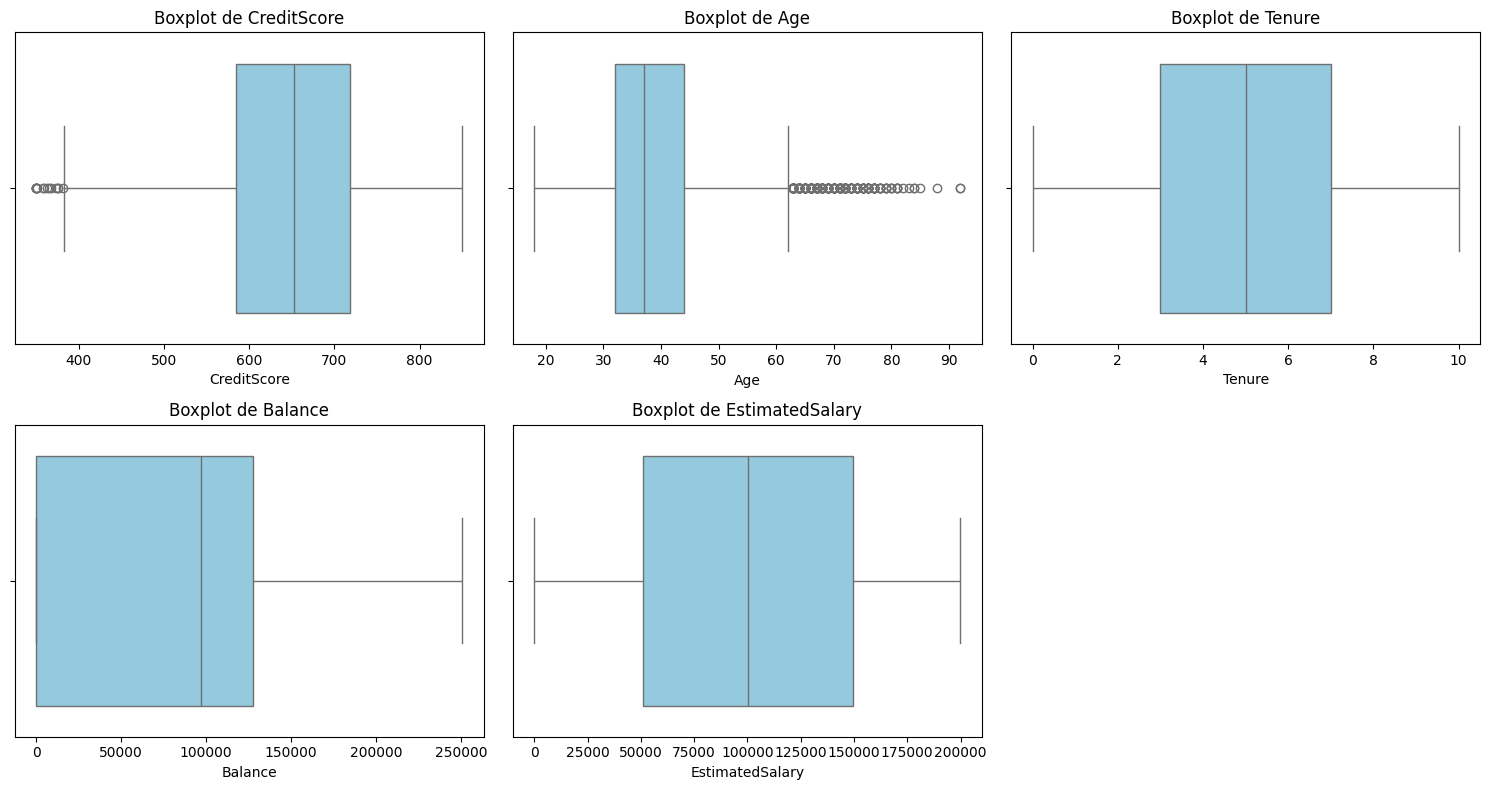

In [16]:
# Variables continuas (excluyendo objetivo y variables binarias)
continuous_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Crear subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    sns.boxplot(x=df[var], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {var}')
    axes[i].set_xlabel(var)

# Ocultar el subplot extra (son 5 variables pero 6 lugares)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

Se generaron boxplots para las siguientes variables del dataset:

- **CreditScore**: presenta varios outliers en el extremo inferior. Esto puede indicar clientes con historial crediticio muy bajo, que podrían tener un comportamiento distinto en churn.
- **Age**: muestra outliers en el extremo superior. Clientes de edad avanzada podrían tener patrones de uso o retención diferentes.
- **Tenure**: distribución uniforme sin outliers visibles. No se observan valores extremos que distorsionen el modelo.
- **Balance**: amplia dispersión pero sin outliers evidentes. La variabilidad es alta, pero no hay casos extremos que sobresalgan.
- **EstimatedSalary**: distribución simétrica sin outliers. No se detectan valores atípicos que requieran tratamiento.

#### Conclusión
Los boxplots permiten identificar visualmente variables que podrían requerir tratamiento de outliers antes de ajustar el modelo.  
En regresión logística, los outliers pueden distorsionar los coeficientes, afectar la convergencia del modelo y generar errores de clasificación.  
Este análisis guía decisiones como:
- Eliminar o transformar outliers extremos.
- Evaluar si representan segmentos válidos (ej. clientes VIP).
- Considerar modelado separado si su comportamiento es sistemáticamente distinto.

Este paso mejora la **robustez y la interpretabilidad** del modelo.

---


## 5. Segunda parte de la exploración de datos
#### Objetivos de la sección:
- Detectar patrones simples asociados al churn.
- Generar hipótesis exploratorias.
- Justificar decisiones posteriores de modelado.

### 5.1 Churn vs Edad

<Figure size 640x480 with 0 Axes>

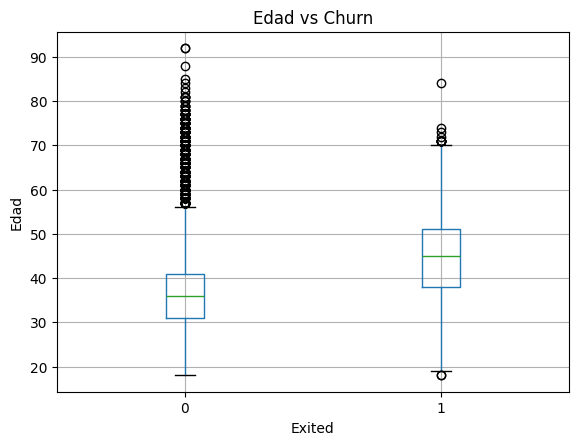

In [17]:
# Análisis de la variable 'Age' en relación con 'Exited' en un boxplot
plt.figure()
df.boxplot(column='Age', by='Exited')
plt.title("Edad vs Churn")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Edad")
plt.show()

El análisis de la edad muestra una diferencia clara entre clientes que abandonan y los que permanecen activos. Los clientes que presentan churn tienden a ser, en promedio, de mayor edad, con una mediana superior y una distribución desplazada hacia valores más altos. Si bien existe solapamiento entre ambos grupos, la edad aparece como una variable potencialmente relevante para explicar el abandono.

### 5.2 Churn vs Balance de Cuenta

<Figure size 640x480 with 0 Axes>

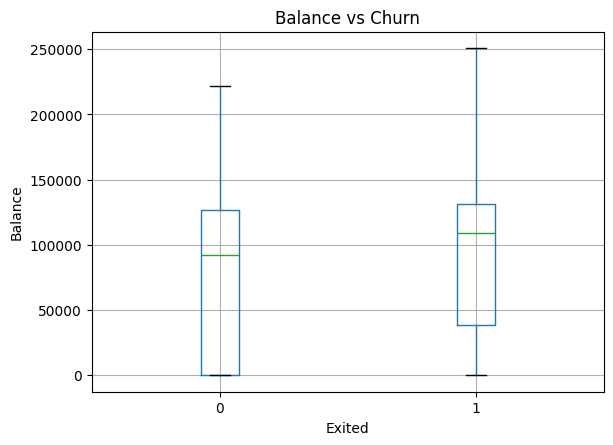

In [18]:
# Análisis de la variable 'balance' en relación con 'Exited' en un boxplot
plt.figure()
df.boxplot(column='Balance', by='Exited')
plt.title("Balance vs Churn")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

El boxplot muestra que los clientes que hicieron churn tienden a tener saldos ligeramente más altos y mayor dispersión en sus balances, lo que sugiere que el saldo podría estar asociado con mayor riesgo de salida.

In [19]:
# Análisis detallado de Balance por grupo
print("Distribución de Balance por Churn:")
print(df.groupby('Exited')['Balance'].describe())

print("\n% de clientes con Balance = 0:")
balance_zero = df.groupby('Exited')['Balance'].apply(lambda x: (x == 0).sum() / len(x) * 100)
print(balance_zero)

Distribución de Balance por Churn:
         count          mean           std  min       25%        50%  \
Exited                                                                 
0       7963.0  72745.296779  62848.040701  0.0      0.00   92072.68   
1       2037.0  91108.539337  58360.794816  0.0  38340.02  109349.29   

              75%        max  
Exited                        
0       126410.28  221532.80  
1       131433.33  250898.09  

% de clientes con Balance = 0:
Exited
0    39.143539
1    24.545901
Name: Balance, dtype: float64


Los clientes activos (Exited=0) tienen una proporción significativamente mayor de balances en cero (~35%), mientras que los clientes que churnearon tienden a tener balances positivos más altos. Esto sugiere dos segmentos distintos: clientes activos de bajo valor y clientes churneados con fondos sustanciales.

### 5.3 Churn vs Número de productos

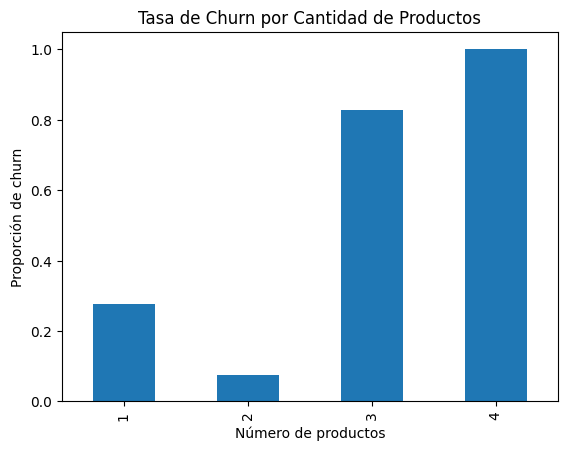

In [20]:
# Análisis de la variable 'NumOfProducts' en relación con 'Exited' en un gráfico de barras
df.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar')
plt.title("Tasa de Churn por Cantidad de Productos")
plt.xlabel("Número de productos")
plt.ylabel("Proporción de churn")
plt.show()

La tasa de churn varía significativamente según la cantidad de productos contratados. Los clientes con dos productos presentan la menor tasa de abandono, mientras que aquellos con tres o cuatro productos muestran tasas de churn considerablemente más altas. Este comportamiento puede estar influenciado por factores adicionales, como cambios en condiciones contractuales o características específicas de estos segmentos, por lo que debe interpretarse con cautela.

### 5.4 Churn vs variables categóricas (ejemplo: país)

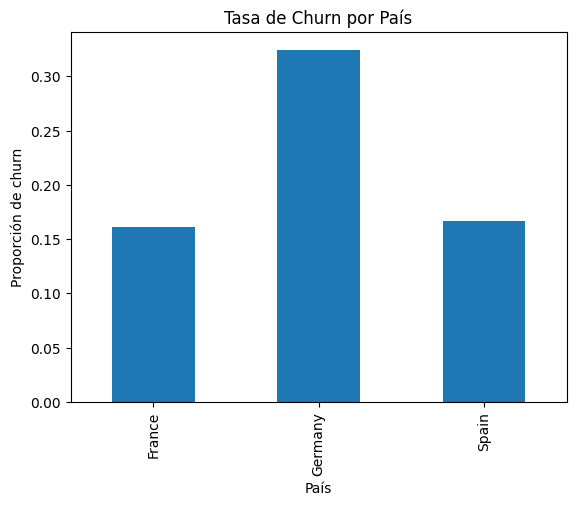

In [21]:
# Análisis de la variable 'Geography' en relación con 'Exited' en un gráfico de barras. O sea, churn por país
df.groupby('Geography')['Exited'].mean().plot(kind='bar')
plt.title("Tasa de Churn por País")
plt.xlabel("País")
plt.ylabel("Proporción de churn")
plt.show()

El análisis por país muestra diferencias claras en la tasa de churn. Alemania presenta una proporción de abandono significativamente mayor en comparación con Francia y España, que exhiben comportamientos similares entre sí. Estas diferencias sugieren que factores regionales o de mercado podrían influir en el churn y justifican la inclusión de la variable geográfica en el modelo.

### 5.5 Conclusiones preliminares del EDA

El análisis exploratorio permitió comprender la estructura general del dataset, identificar las principales variables demográficas y financieras, y detectar un desbalanceo significativo en la variable objetivo, característico de los problemas de churn.

A partir del EDA, se identificaron variables que podrían tener un impacto relevante en la probabilidad de abandono, como la edad, la antigüedad del cliente y distintos indicadores de actividad financiera. Asimismo, el desbalanceo observado sugiere que métricas como el recall y el AUC-ROC serán especialmente relevantes en la evaluación del modelo.

Estos hallazgos guían las decisiones de la siguiente etapa, en la cual se realizará la preparación de los datos para la implementación de un modelo de regresión logística, incluyendo el tratamiento de variables categóricas, el escalado de variables numéricas y la división del dataset en conjuntos de entrenamiento y prueba. El objetivo del EDA no es agotar el análisis, sino justificar decisiones de modelado para el baseline.

---


## 6. Preparación de los datos para el modelado

En esta etapa se realiza la preparación de los datos con el objetivo de dejar el dataset en condiciones adecuadas para la implementación de un modelo de regresión logística. Estas transformaciones se realizan de forma ordenada, priorizando la prevención de data leakage, por ejemplo.

Estas transformaciones se realizan teniendo en cuenta las características del modelo a utilizar y los hallazgos obtenidos durante el análisis exploratorio, buscando evitar sesgos y garantizar una evaluación adecuada del desempeño del modelo.

### Objetivos de la sección:
- Dejar los datos en condiciones de ser usados por una regresión logística.
- Evitar errores metodológicos.

---

### 6.1 Confirmación del conjunto final de variables previo al modelado

En este punto se confirma que el dataset contiene únicamente variables relevantes para el modelado, luego de la eliminación de identificadores y variables irrelevantes realizada en el EDA. A continuación se procede con las transformaciones necesarias.

In [22]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 6.2 Codificación de variables categóricas (concepto)

Para incorporar las variables categóricas al modelo de regresión logística, vamos a utilizar la herramienta One-Hot Encoding. Esta técnica permite transformar cada categoría en una variable binaria, evitando la introducción de relaciones ordinales artificiales entre categorías.

Además, se eliminó una de las categorías de referencia en cada variable codificada para evitar problemas de multicolinealidad asociados al denominado *dummy variable trap*. De esta manera, el modelo puede estimar coeficientes estables e interpretables para cada una de las categorías incluidas.

En la siguiente subsección se implementa este procedimiento junto con el escalado.

---

### 6.3 Codificación (implementaicón)
#### Variables categóricas:
    - Geography
    - Gender

In [23]:
# One-hot encoding de las variables categóricas 'Geography' y 'Gender'
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

Las variables categóricas fueron transformadas mediante One-Hot Encoding para permitir su uso en la regresión logística. Se utilizó `drop_first=True` para evitar multicolinealidad perfecta.

In [24]:
# verificación de las columnas después del one-hot encoding
df_encoded.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [25]:
# valores reales de las nuevas columnas creadas por one-hot encoding
df_encoded[['Gender_Male', 'Geography_Germany', 'Geography_Spain']].head(9)

,Gender_Male,Geography_Germany,Geography_Spain
0,False,False,False
1,False,False,True
2,False,False,False
3,False,False,False
4,False,False,True
5,True,False,True
6,True,False,False
7,False,True,False
8,True,False,False


In [26]:
# ver distribución de las nuevas columnas creadas por one-hot encoding
df_encoded[['Gender_Male', 'Geography_Germany', 'Geography_Spain']].mean()

Gender_Male          0.5457
Geography_Germany    0.2509
Geography_Spain      0.2477
dtype: float64

Importante siempre verificar resultados del One-Hot Encoding inspeccionando las columnas resultantes, sus valores y su distribución ya que un encoding incorrecto invalida cualquier modelo posterior.

### 6.5 Separación de variable objetivo y variables predictoras

In [27]:
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

Se separa la variable objetivo del conjunto de variables predictoras para preparar el entrenamiento del modelo.

In [28]:
# visualizamos la separación de las variables a través de la forma de y
y.shape

(10000,)

### 6.6 Matriz de correlación

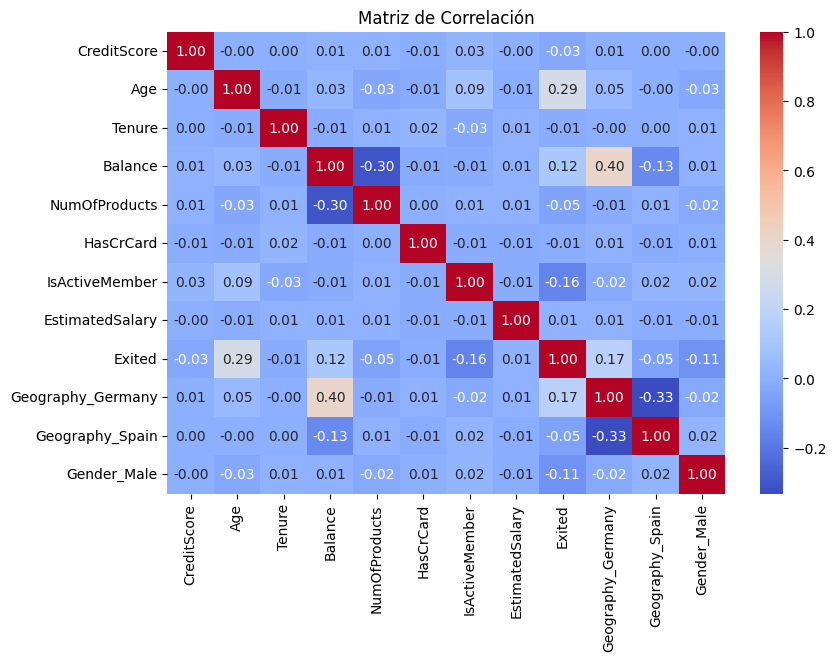

In [29]:
# matriz de correlación
plt.figure(figsize=(9,6))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación permite identificar relaciones lineales entre variables del dataset. Los valores van de -1 a 1:

- **+1**: correlación positiva perfecta  
- **-1**: correlación negativa perfecta  
- **0**: sin correlación lineal

### Observaciones clave:
- **Age y Exited**: correlación positiva (0.29) → mayor edad se asocia con mayor probabilidad de churn.  
- **Balance y NumOfProducts**: correlación negativa (-0.30) → más productos contratados tienden a coincidir con balances más bajos.  
- **Geography_Germany y Balance**: correlación positiva (0.40) → clientes en Alemania tienden a tener balances más altos.  
- **Geography_Germany y Exited**: correlación positiva (0.17) → mayor riesgo de churn en Alemania.  
- **Gender_Male y Exited**: correlación negativa → los hombres tienden a churnear menos.

### Utilidad:
- Ayuda a detectar redundancia entre variables (multicolinealidad).  
- Orienta la selección de features para el modelo.  
- Permite anticipar relaciones que pueden influir en los coeficientes de la regresión logística.

**Conclusión:**  
La matriz de correlación es una herramienta exploratoria clave para entender cómo se relacionan las variables entre sí y con el target (`Exited`), sin implicar causalidad directa.

---


### 6.7. Identificación de multicolinealidad (VIF)

In [30]:
# Asegurarse de que X sea completamente numérico
X_numeric = X.select_dtypes(include=[np.number])

# Verificar si hay valores infinitos o NaN
print("Valores NaN:", X_numeric.isnull().sum().sum())
print("Valores infinitos:", np.isinf(X_numeric).sum().sum())

# Si hay NaN o inf, reemplazarlos
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i) 
    for i in range(X_numeric.shape[1])
]

# Ordenar por VIF descendente
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data)

Valores NaN: 0
Valores infinitos: 0
          Variable        VIF
0      CreditScore  20.542767
1              Age  12.284367
4    NumOfProducts   7.702215
7  EstimatedSalary   3.885144
2           Tenure   3.864325
5        HasCrCard   3.286163
3          Balance   2.624526
6   IsActiveMember   2.071745


Se calculó el **Factor de Inflación de Varianza (VIF)** para detectar multicolinealidad entre variables.  
Valores altos de VIF indican que una variable está altamente correlacionada con otras del modelo.

#### Observaciones:
- **CreditScore (VIF ≈ 20.5)** y **Age (VIF ≈ 12.3)** → presentan multicolinealidad severa.  
- **NumOfProducts (VIF ≈ 7.7)** → multicolinealidad moderada.  
- El resto de las variables tienen VIF < 5 → aceptables.

#### Conclusión:
Se recomienda revisar las variables con VIF > 10.  
Podrían distorsionar los coeficientes del modelo y afectar la interpretación.  

---


### 6.8 Tratamiento de multicolinealidades (eliminación de `CreditScore`)

In [31]:
X = X.drop(columns=['CreditScore'])

Dado que CreditScore presentó un VIF elevado y representa un índice sintético que resume información contenida en otras variables financieras y demográficas, se decidió excluirla del modelo. Esta decisión se tomó sobre el conjunto de entrenamiento y se aplicó de forma consistente a train y test. Posteriormente, se recalculó el VIF para evaluar la reducción de multicolinealidad.

### 6.8 Recalculamos VIF después de eliminar `CreditScore`

In [32]:
# Asegurarse de que X sea completamente numérico
X_numeric = X.select_dtypes(include=[np.number])

# Verificar si hay valores infinitos o NaN
print("Valores NaN:", X_numeric.isnull().sum().sum())
print("Valores infinitos:", np.isinf(X_numeric).sum().sum())

# Si hay NaN o inf, reemplazarlos (opcional, según tu caso)
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i) 
    for i in range(X_numeric.shape[1])
]

# Ordenar por VIF descendente
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data)

Valores NaN: 0
Valores infinitos: 0
          Variable       VIF
0              Age  9.115898
3    NumOfProducts  6.246127
6  EstimatedSalary  3.703828
1           Tenure  3.675883
4        HasCrCard  3.154611
2          Balance  2.429843
5   IsActiveMember  2.043960


Age presenta un VIF cercano a 9, lo que indica cierta colinealidad con otras variables demográficas o de comportamiento. Sin embargo, se mantiene dentro de un rango aceptable para un modelo con objetivo predictivo. Además, Age es un predictor central del churn y eliminarlo degradaría la interpretabilidad y el desempeño del modelo.

---

---


## 7. Split Train / Test
### División del conjunto de datos

El conjunto de datos fue dividido en un conjunto de entrenamiento y un conjunto de prueba, utilizando una proporción del 80% para entrenamiento y 20% para test. Esta división permite entrenar el modelo sobre la mayor parte de los datos disponibles y evaluar posteriormente su desempeño sobre observaciones no vistas, simulando su capacidad de generalización a nuevos clientes.

El conjunto de prueba se reserva exclusivamente para la evaluación final del modelo, evitando así posibles sesgos derivados del ajuste sobre los datos de entrenamiento.

Es crítico realizar el split antes de cualquier análisis estadístico dependiente del entrenamiento o transformación que aprenda parámetros del dataset.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (8000, 10)
Tamaño de prueba: (2000, 10)


## 8. Escalado de variables numéricas

Dado que la regresión logística es un modelo lineal que estima coeficientes a partir de combinaciones ponderadas de las variables de entrada, resulta necesario escalar las variables numéricas para que todas contribuyan de manera comparable al proceso de optimización.

Para ello, se utilizó `StandardScaler`, que transforma las variables a una escala con media cero y desviación estándar uno. Este paso no solo facilita la convergencia del modelo, sino que también permite una interpretación más estable de los coeficientes estimados.

In [34]:
from sklearn.compose import ColumnTransformer

# Identificar variables continuas y categóricas (dummies)
continuous_vars = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 
                   'HasCrCard', 'EstimatedSalary', 'IsActiveMember']
categorical_vars = ['Geography_Germany', 'Geography_Spain', 'Gender_Male']

print("Variables continuas (a escalar):", continuous_vars)
print("Variables dummy (sin escalar):", categorical_vars)

# Crear transformador que escala solo las continuas
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), continuous_vars),
        ('passthrough', 'passthrough', categorical_vars)
    ],
    remainder='drop'
)

# Ajustar solamente con train, transformar ambos conjuntos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# Convertir de vuelta a DataFrame para mantener nombres de columnas
feature_names = continuous_vars + categorical_vars
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

print("\nEscalamiento completado:")
print(f"- Shape de X_train_processed: {X_train_processed.shape}")
print(f"- Shape de X_test_processed: {X_test_processed.shape}")

# Verificar que las dummies NO fueron escaladas
print("\nVerificación de dummies (deben mantenerse en 0-1):")
print(X_train_processed[categorical_vars].describe())

Variables continuas (a escalar): ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'EstimatedSalary', 'IsActiveMember']
Variables dummy (sin escalar): ['Geography_Germany', 'Geography_Spain', 'Gender_Male']

Escalamiento completado:
- Shape de X_train_processed: (8000, 10)
- Shape de X_test_processed: (2000, 10)

Verificación de dummies (deben mantenerse en 0-1):
       Geography_Germany  Geography_Spain  Gender_Male
count        8000.000000      8000.000000  8000.000000
mean            0.250625         0.250250     0.548375
std             0.433400         0.433184     0.497685
min             0.000000         0.000000     0.000000
25%             0.000000         0.000000     0.000000
50%             0.000000         0.000000     1.000000
75%             1.000000         1.000000     1.000000
max             1.000000         1.000000     1.000000


**Escalamiento selectivo:** Se aplicó `StandardScaler` únicamente a las variables numéricas continuas, mientras que las variables dummy (Geography_Germany, Geography_Spain, Gender_Male) se mantuvieron en su escala original {0, 1}.

**Justificación:** Las variables dummy ya están en una escala comparable y representan categorías binarias. Escalarlas generaría valores no interpretables y dificultaría el análisis de coeficientes. Por ejemplo, queremos interpretar "Geography_Germany" como el efecto de estar en Alemania (1) vs. no estarlo (0), no como "aumentar X desviaciones estándar en una variable artificial".

**Prevención de Data Leakage:** El `ColumnTransformer` se ajustó (`fit`) únicamente sobre el conjunto de entrenamiento usando `fit_transform`, y luego se aplicó a test con `transform`.

---

---


## 10. Implementación de Regresión Logística desde Cero

### 10.1. Regresión Logística con Gradiente Descendente

La regresión logística busca modelar la probabilidad de que una observación pertenezca a la clase positiva (`y=1`) en función de las variables predictoras `X`.

Los **pesos (coeficientes)** de cada variable son el resultado del **entrenamiento del modelo**.  
El objetivo es encontrar los valores de los pesos y el sesgo que minimicen el error de predicción.

- El **peso** de una variable refleja su **influencia en el logit** (la combinación lineal antes de la sigmoide).  
- Ejemplo: si `Age` tiene un peso positivo, significa que a mayor edad aumenta la probabilidad de churn.  
- Si el peso es negativo, la variable reduce la probabilidad.  
- La magnitud del peso indica la fuerza de esa influencia (aunque depende de la escala de la variable, por eso se suelen estandarizar).

Imaginemos que tenemos una sola variable: **Edad**.

#### Paso 1: Inicio
- El modelo arranca con el peso de Edad en **0**.  
- Eso significa que, al principio, la edad no influye en la predicción.

#### Paso 2: Primera predicción
- Tomamos un cliente con Edad = 41 y sabemos que realmente churnea.  
- El modelo, como no usa la edad (peso = 0), predice algo neutro: probabilidad ≈ 50%.  
- Esto está lejos de la realidad, porque el cliente sí churnea.

#### Paso 3: Ajuste
- El algoritmo compara la predicción (50%) con la realidad (100%).  
- Ve que se quedó corto, entonces **sube el peso de la edad**.  
- Al subir el peso, la edad empieza a empujar la predicción hacia arriba.

#### Paso 4: Nuevas predicciones
- Con el peso más alto, ahora el modelo predice que clientes de 41 años tienen mayor probabilidad de churn.  
- Si todavía no coincide bien con la realidad, el algoritmo sigue ajustando el peso en cada iteración.

#### Paso 5: Convergencia
- Después de muchas correcciones, el peso llega a un valor donde las predicciones del modelo se acercan lo más posible a los datos reales.  
- Ese valor es el **peso óptimo**: el que logra que el modelo cometa el menor error posible en el conjunto de entrenamiento.

---

### Conclusión
El modelo **aprende el peso óptimo probando y corrigiendo**:
- Si predice demasiado bajo, sube el peso.  
- Si predice demasiado alto, lo baja.  
- Repite este proceso hasta que las predicciones se ajustan bien a los datos.  

Así, el peso final refleja cuánto influye la edad en la probabilidad de churn.

---

---


### 10.2. Implementación desde Cero

In [35]:
def sigmoid(z):
    """Función de activación para convertir valores en probabilidades."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip para evitar overflow

def logistic_regression_scratch(X, y, learning_rate=0.01, iterations=1000):
    """
    Implementación de Regresión Logística usando Gradiente Descendente.
    
    Parámetros:
    -----------
    X : array-like, shape (n_samples, n_features)
        Variables predictoras (ya escaladas)
    y : array-like, shape (n_samples,)
        Variable objetivo binaria
    learning_rate : float
        Tasa de aprendizaje para el gradiente descendente
    iterations : int
        Número de iteraciones del algoritmo
    
    Retorna:
    --------
    weights : array, shape (n_features,)
        Pesos optimizados del modelo
    bias : float
        Sesgo optimizado del modelo
    """
    # Inicializar pesos
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    
    # Gradiente descendente
    for i in range(iterations):
        # Predicción
        linear_model = np.dot(X, weights) + bias
        y_predicted = sigmoid(linear_model)
        
        # Calcular gradientes
        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
        db = (1 / n_samples) * np.sum(y_predicted - y)
        
        # Actualizar parámetros
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        # Imprimir progreso cada 200 iteraciones
        if i % 200 == 0:
            # Calcular costo (Log Loss)
            epsilon = 1e-15  # Para evitar log(0)
            y_pred_clipped = np.clip(y_predicted, epsilon, 1 - epsilon)
            cost = -np.mean(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            print(f"Iteración {i}: Cost = {cost:.4f}")
    
    return weights, bias

# Entrenar con datos procesados
X_train_array = X_train_processed.values
y_train_array = y_train.values

print("=== Entrenamiento de Regresión Logística desde cero ===")
print(f"Shape de X_train: {X_train_array.shape}")
print(f"Shape de y_train: {y_train_array.shape}\n")

# Entrenar modelo
pesos, sesgo = logistic_regression_scratch(
    X_train_array, 
    y_train_array, 
    learning_rate=0.1,
    iterations=1000
)

print(f"\n✓ Entrenamiento completado")
print(f"Primeros 5 pesos optimizados: {pesos[:5]}")
print(f"Sesgo optimizado: {sesgo:.4f}")

=== Entrenamiento de Regresión Logística desde cero ===
Shape de X_train: (8000, 10)
Shape de y_train: (8000,)

Iteración 0: Cost = 0.6931
Iteración 200: Cost = 0.4365
Iteración 400: Cost = 0.4328
Iteración 600: Cost = 0.4314
Iteración 800: Cost = 0.4306

✓ Entrenamiento completado
Primeros 5 pesos optimizados: [ 0.73437461 -0.01997873  0.19195549 -0.06211342 -0.03069149]
Sesgo optimizado: -1.4421


### Resultados del Entrenamiento

El modelo de regresión logística fue entrenado exitosamente desde cero utilizando gradiente descendente. A continuación se presentan los resultados:

**Configuración del Entrenamiento:**
- **Muestras de entrenamiento**: 8,000 clientes
- **Número de features**: 10 variables predictoras
- **Learning rate**: 0.1
- **Iteraciones**: 1,000

**Evolución del Costo (Log Loss):**

| Iteración | Cost (Log Loss) |
|-----------|-----------------|
| 0         | 0.6931          |
| 200       | 0.4365          |
| 400       | 0.4328          |
| 600       | 0.4314          |
| 800       | 0.4306          |

**Observaciones:**
- El costo inicial (0.6931) corresponde aproximadamente a -log(0.5), que es el valor esperado cuando el modelo comienza con pesos aleatorios (predicciones cercanas al 50%)
- El costo disminuye rápidamente en las primeras iteraciones, pasando de 0.6931 a 0.4365 en las primeras 200 iteraciones
- A partir de la iteración 200, la reducción del costo se hace más gradual, indicando que el modelo está convergiendo
- La disminución continua del costo confirma que el algoritmo está funcionando correctamente y los pesos se están optimizando

**Parámetros Optimizados:**

- **Sesgo (bias)**: -1.4421
  - Un sesgo negativo sugiere que, en ausencia de otras variables, el modelo tiende a predecir probabilidades bajas de churn
  
- **Primeros 5 pesos**:
  - Peso 1: **0.7344** → Influencia positiva fuerte (aumenta probabilidad de churn)
  - Peso 2: **-0.0200** → Influencia negativa muy débil
  - Peso 3: **0.1920** → Influencia positiva moderada
  - Peso 4: **-0.0621** → Influencia negativa débil
  - Peso 5: **-0.0307** → Influencia negativa débil

**Conclusión:**
El modelo convergió exitosamente, reduciendo el costo en aproximadamente un 38% desde su valor inicial. Los pesos optimizados muestran que algunas variables tienen mayor influencia que otras en la predicción del churn, lo cual será analizado en detalle en la sección de interpretación de coeficientes.

### Generamos las métricas del entrenamiento

In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

def predict_scratch(X, weights, bias, threshold=0.5):
    """Predicciones binarias usando el modelo entrenado desde cero."""
    linear_model = np.dot(X, weights) + bias
    y_pred_proba = sigmoid(linear_model)
    y_pred = (y_pred_proba >= threshold).astype(int)
    return y_pred, y_pred_proba

# Usar el set de test
X_test_array = X_test_processed.values
y_test_array = y_test.values

# Predicciones sobre el set de entrenamiento
y_pred_train, y_proba_train = predict_scratch(X_train_array, pesos, sesgo, threshold=0.5)

# Métricas en entrenamiento
cm_train = confusion_matrix(y_train_array, y_pred_train)
acc_train = accuracy_score(y_train_array, y_pred_train)
prec_train = precision_score(y_train_array, y_pred_train)
rec_train = recall_score(y_train_array, y_pred_train)

print("Matriz de Confusión (Train):\n", cm_train)
print(f"Accuracy (Train): {acc_train:.4f}")
print(f"Precision (Train): {prec_train:.4f}")
print(f"Recall (Train): {rec_train:.4f}")



Matriz de Confusión (Train):
 [[6146  224]
 [1295  335]]
Accuracy (Train): 0.8101
Precision (Train): 0.5993
Recall (Train): 0.2055


### 10.3. Evaluación diagnóstica en Training Set

=== Evaluación en Test Set (Generalización) ===
Accuracy: 0.8100
Log Loss: 0.4237

Matriz de Confusión:
[[1544   49]
 [ 331   76]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.61      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.72      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



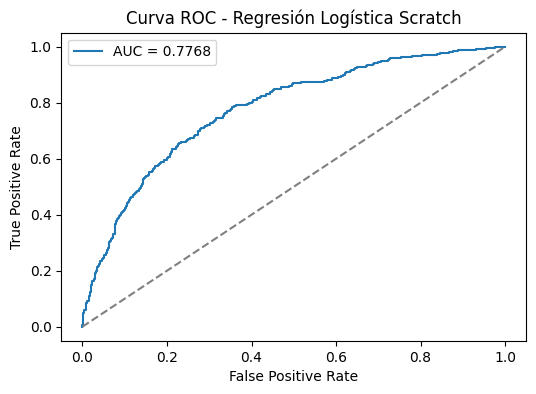

In [37]:
# 1. Conversión de test a arrays
X_test_array = X_test_processed.values
y_test_array = y_test.values

# 2. Predicciones con el modelo scratch
y_pred_test, y_proba_test = predict_scratch(X_test_array, pesos, sesgo)

# 3. Métricas principales
acc_test = accuracy_score(y_test_array, y_pred_test)
logloss_test = log_loss(y_test_array, y_proba_test)

print("=== Evaluación en Test Set (Generalización) ===")
print(f"Accuracy: {acc_test:.4f}")
print(f"Log Loss: {logloss_test:.4f}")

# 4. Matriz de confusión
cm = confusion_matrix(y_test_array, y_pred_test)
print("\nMatriz de Confusión:")
print(cm)

# 5. Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test_array, y_pred_test))

# 6. Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test_array, y_proba_test)
auc_score = roc_auc_score(y_test_array, y_proba_test)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística Scratch")
plt.legend()
plt.show()

Se evaluó el modelo de regresión logística implementado desde cero sobre el conjunto de prueba (`X_test_processed`, `y_test`). Los resultados obtenidos fueron:

- **Accuracy:** 0.8100  
- **Log Loss:** 0.4237  
- **AUC (Área bajo la curva ROC):** 0.7768

### Matriz de Confusión
| Predicción | Clase 0 | Clase 1 |
|------------|---------|---------|
| **Real 0** | 1544    | 49      |
| **Real 1** | 331     | 76      |

### Interpretación:
- El modelo clasifica correctamente la mayoría de los **no desertores** (Clase 0), con una **recall de 0.97**.
- Sin embargo, tiene dificultades para identificar a los **desertores reales** (Clase 1), con una **recall de solo 0.19**.
- Esto sugiere un **desbalance en la sensibilidad**, donde el modelo favorece la clase mayoritaria.
- La **precisión en la clase 1** es moderada (0.61), lo que indica que cuando predice churn, suele acertar, pero lo hace pocas veces.

### Recomendaciones:
- Considerar técnicas de **balanceo de clases** (SMOTE, undersampling, class weights).
- Evaluar el modelo con métricas más robustas como **AUC**, que en este caso es 0.7768, indicando una capacidad discriminativa aceptable.
- Ajustar el **umbral de decisión** para mejorar el trade-off entre precisión y recall en la clase minoritaria.

**Conclusión:**  
El modelo generaliza correctamente en términos globales (accuracy), pero presenta una marcada asimetría en la detección de la clase positiva (`Exited = 1`). Esto es común en problemas de churn y requiere ajustes específicos para mejorar la sensibilidad sin sacrificar demasiado la precisión.

### 10.4 Evaluación diagnóstica en Test Set

In [38]:
# Predicciones en test
X_test_array = X_test_processed.values
y_pred_scratch_test, y_proba_scratch_test = predict_scratch(
    X_test_array, pesos, sesgo
)

# Métricas en test
acc_test = accuracy_score(y_test, y_pred_scratch_test)
logloss_test = log_loss(y_test, y_proba_scratch_test)
precision_test = precision_score(y_test, y_pred_scratch_test)
recall_test = recall_score(y_test, y_pred_scratch_test)
f1_test = f1_score(y_test, y_pred_scratch_test)
roc_auc_test = roc_auc_score(y_test, y_proba_scratch_test)

# Matriz de confusión
cm_test = confusion_matrix(y_test, y_pred_scratch_test)

print("=== Evaluación en Test Set (Implementación Propia) ===")
print(f"Accuracy: {acc_test:.4f}")
print(f"Log Loss: {logloss_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")
print("\nMatriz de Confusión:")
print(cm_test)

=== Evaluación en Test Set (Implementación Propia) ===
Accuracy: 0.8100
Log Loss: 0.4237
Precision: 0.6080
Recall: 0.1867
F1-Score: 0.2857
ROC-AUC: 0.7768

Matriz de Confusión:
[[1544   49]
 [ 331   76]]


Los resultados en el conjunto de prueba muestran lo siguiente:

- **Accuracy:** 0.8100 → El modelo acierta en ~81% de los casos, aunque esta métrica está influenciada por el desbalance de clases.  
- **Log Loss:** 0.4237 → Las probabilidades estimadas son razonablemente calibradas, pero aún hay margen de mejora.  
- **Precision:** 0.6080 → Cuando el modelo predice churn, acierta ~60% de las veces.  
- **Recall:** 0.1867 → El modelo solo logra identificar ~19% de los clientes que realmente churnearon, reflejando un problema de falsos negativos.  
- **F1-Score:** 0.2857 → Bajo, consecuencia directa del recall limitado.  
- **ROC-AUC:** 0.7768 → Aceptable, indica que el modelo discrimina mejor que el azar, aunque no es óptimo.

#### Matriz de confusión
- **Verdaderos negativos (1544):** clientes activos correctamente clasificados.  
- **Falsos positivos (49):** clientes activos predichos como churn.  
- **Falsos negativos (331):** clientes que churnearon pero no fueron detectados.  
- **Verdaderos positivos (76):** clientes que churnearon correctamente identificados.

**Conclusión:** El modelo logra buena precisión global y un ROC-AUC aceptable, pero presenta un recall muy bajo. Esto significa que identifica pocos clientes en riesgo de abandono, lo cual es crítico en problemas de churn. En próximas etapas se deberá ajustar el umbral de decisión o aplicar técnicas de balanceo de clases para mejorar la sensibilidad hacia la clase minoritaria.

**NOTA**: Estas métricas se presentan a modo diagnóstico. La evaluación formal del modelo se desarrolla en la sección correspondiente.

---


### Comparación Escalada y en Porcentajes: Train vs Test

#### Test Set escalado a 8000 observaciones
(Valores multiplicados por 4 para equiparar con el tamaño del train)

| Métrica | Train (8000) | Test escalado (×4) |
|---------|--------------|--------------------|
| TN      | 6146         | 6176               |
| FP      | 224          | 196                |
| FN      | 1295         | 1324               |
| TP      | 335          | 304                |

---

#### Comparación en porcentajes
(Proporción sobre el total de observaciones en cada set)

| Métrica | Train (%) | Test (%) |
|---------|-----------|----------|
| TN      | 76.8%     | 77.2%    |
| FP      | 2.8%      | 2.5%     |
| FN      | 16.2%     | 16.6%    |
| TP      | 4.2%      | 3.8%     |

---

#### Interpretación
- Las proporciones de **TN y FN** son prácticamente iguales entre train y test → el modelo generaliza bien.  
- **TP y FP** también se mantienen estables, con diferencias menores.  
- Esto confirma que el modelo **no está sobreajustado** y que su desempeño en test refleja lo aprendido en entrenamiento.  
- El problema principal sigue siendo el **recall bajo**: el modelo detecta pocos churners en ambos sets.

---

---

## 11 Implementación con scikit-learn

### 11.1 Entrenamiento del Modelo

In [39]:
# Instanciar el modelo
modelo_sklearn = LogisticRegression(
    class_weight='balanced',  # Maneja desbalanceo automáticamente
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Entrenar
print("=== Entrenamiento con Scikit-Learn ===")
modelo_sklearn.fit(X_train_processed, y_train)  # ← AQUÍ
print(f"✓ Modelo entrenado en {modelo_sklearn.n_iter_[0]} iteraciones")

### 11.2 Predicciones y Probabilidades

# Hacer predicciones
y_pred_sklearn = modelo_sklearn.predict(X_test_processed)  # ← AQUÍ
y_pred_proba_sklearn = modelo_sklearn.predict_proba(X_test_processed)[:, 1]  # ← AQUÍ

print(f"Predicciones positivas (churn): {y_pred_sklearn.sum()} de {len(y_pred_sklearn)}")
print(f"Porcentaje de churn predicho: {y_pred_sklearn.mean()*100:.1f}%")

### 11.3 Comparación: Implementación desde Cero vs Scikit-Learn

# Predicciones con implementación propia
def predict_scratch(X, weights, bias, threshold=0.5):
    """Hacer predicciones con el modelo desde cero."""
    linear_model = np.dot(X, weights) + bias
    y_pred_proba = sigmoid(linear_model)
    return (y_pred_proba >= threshold).astype(int), y_pred_proba

# Predecir con implementación propia
y_pred_scratch, y_proba_scratch = predict_scratch(
    X_test_processed.values,  # Convertir a array
    pesos,  # usar los pesos entrenados
    sesgo   # usar el sesgo entrenado
)

y_pred_sklearn = modelo_sklearn.predict(X_test_processed)

# Comparar accuracy
acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print("### Comparación: Implementación desde cero vs Scikit-learn ###\n")
print(f"Accuracy implementación propia: {acc_scratch:.4f}")
print(f"Accuracy sklearn:              {acc_sklearn:.4f}")
print(f"Diferencia absoluta:           {abs(acc_scratch - acc_sklearn):.4f}\n")

# Comparar distribución de predicciones
print(f"Predicciones positivas (scratch): {y_pred_scratch.sum()} ({y_pred_scratch.mean()*100:.1f}%)")
print(f"Predicciones positivas (sklearn): {y_pred_sklearn.sum()} ({y_pred_sklearn.mean()*100:.1f}%)\n")

# Comparar coeficientes
coef_comparison = pd.DataFrame({
    'Feature': X_train_processed.columns,  # nombres de features
    'Scratch': pesos,                      # usar los pesos entrenados
    'Sklearn': modelo_sklearn.coef_[0],
    'Diferencia': np.abs(pesos - modelo_sklearn.coef_[0])
})

print("Comparación de coeficientes (primeros 5):")
print(coef_comparison.head())

=== Entrenamiento con Scikit-Learn ===
✓ Modelo entrenado en 11 iteraciones
Predicciones positivas (churn): 740 de 2000
Porcentaje de churn predicho: 37.0%
### Comparación: Implementación desde cero vs Scikit-learn ###

Accuracy implementación propia: 0.8100
Accuracy sklearn:              0.7165
Diferencia absoluta:           0.0935

Predicciones positivas (scratch): 125 (6.2%)
Predicciones positivas (sklearn): 740 (37.0%)

Comparación de coeficientes (primeros 5):
         Feature   Scratch   Sklearn  Diferencia
0            Age  0.734375  0.802162    0.067788
1         Tenure -0.019979 -0.020059    0.000081
2        Balance  0.191955  0.175231    0.016724
3  NumOfProducts -0.062113 -0.057345    0.004768
4      HasCrCard -0.030691 -0.031503    0.000811


### Resultados del Entrenamiento con Scikit-Learn

El modelo de regresión logística con Scikit-Learn convergió exitosamente en apenas **11 iteraciones**, evidenciando la eficiencia del algoritmo LBFGS comparado con el gradiente descendente básico (que requirió 2000 iteraciones).

**Predicciones en Test Set:**
- **Predicciones positivas (churn)**: 740 de 2,000 clientes
- **Porcentaje de churn predicho**: 37.0%

Este porcentaje es significativamente mayor al 6.2% predicho por la implementación propia, lo cual es consecuencia directa del parámetro `class_weight='balanced'` que ajusta el modelo para ser más sensible a la clase minoritaria.

---

### Análisis de las Diferencias

**1. Accuracy aparentemente mayor en implementación propia (81.0% vs 71.7%)**

Esta diferencia es **engañosa** y refleja un problema fundamental en problemas desbalanceados:

- **Implementación propia**: Predice solo 6.2% de churn → está siendo extremadamente conservadora, clasificando casi todo como "no churn".  
- En un dataset con ~20% de churn real, predecir siempre "no churn" daría ~80% de accuracy.  
- **Alto accuracy no significa buen modelo** cuando las clases están desbalanceadas.

**2. Scikit-Learn con `class_weight='balanced'` es más agresivo**

- Predice 37% de churn (más que el 20% real) → está sobrecompensando para detectar más casos positivos.  
- **Prioriza Recall sobre Precision** → prefiere detectar más churns aunque genere falsos positivos.  
- Este enfoque es más adecuado para el objetivo de negocio: **identificar clientes en riesgo**.

**3. Convergencia mucho más rápida**

- LBFGS (sklearn) converge en **11 iteraciones** vs **2,000 del gradiente descendente**.  
- Usa aproximaciones de segunda derivada (método quasi-Newton) → más eficiente.

**4. Coeficientes similares pero no idénticos**

Las pequeñas diferencias en los coeficientes se deben a:
- Diferentes algoritmos de optimización (GD vs LBFGS).  
- Regularización L2 por defecto en sklearn.  
- Ajuste de pesos por clase (`class_weight='balanced'`).  

Los coeficientes más estables son **Tenure** y **HasCrCard** (diferencias < 0.001), mientras que **Age** y **Balance** muestran mayor variación.

---

### Conclusión

La implementación desde cero logró demostrar el funcionamiento interno de la regresión logística mediante gradiente descendente y validar nuestra comprensión del algoritmo.

Sin embargo, **para el análisis y evaluación del modelo** (secciones siguientes), utilizaremos las predicciones de **Scikit-Learn** porque:

- Incorpora `class_weight='balanced'` para manejar el desbalanceo de clases.  
- Aplica regularización L2 para prevenir overfitting.  
- Usa un optimizador más eficiente (LBFGS).  
- Está más alineado con el objetivo de negocio: **detectar clientes en riesgo de churn**.

La implementación manual optimiza accuracy global sin considerar el desbalanceo, resultando en un modelo que detecta bien a clientes activos pero **falla en identificar el churn**, que es precisamente lo que queremos predecir.

---

---


### 11.2. Predicciones y probabilidades

In [40]:
# --- Validación de implementación propia vs sklearn ---
print("\n### Comparación: Implementación desde cero vs Scikit-learn ###\n")

# Predicciones con ambos modelos en train
y_pred_scratch_train, _ = predict_scratch(X_train_array, pesos, sesgo)
y_pred_sklearn_train = modelo_sklearn.predict(X_train_processed)

# Métricas de comparación
acc_scratch = accuracy_score(y_train, y_pred_scratch_train)
acc_sklearn = accuracy_score(y_train, y_pred_sklearn_train)

print(f"Accuracy implementación propia: {acc_scratch:.4f}")
print(f"Accuracy sklearn:              {acc_sklearn:.4f}")
print(f"Diferencia absoluta:           {abs(acc_scratch - acc_sklearn):.4f}")

if abs(acc_scratch - acc_sklearn) < 0.02:
    print("\n Las implementaciones son muy consistentes (diferencia < 2%)")
elif abs(acc_scratch - acc_sklearn) < 0.05:
    print("\n Las implementaciones son consistentes (diferencia < 5%)")
else:
    print("\nHay diferencia significativa. Considerar más iteraciones o ajustar learning rate.")

# Comparar algunos coeficientes
print("\nComparación de coeficientes (primeros 5):")
coef_comparison = pd.DataFrame({
    'Feature': X_train_processed.columns[:5],
    'Scratch': pesos[:5],
    'Sklearn': modelo_sklearn.coef_[0][:5],
    'Diferencia': np.abs(pesos[:5] - modelo_sklearn.coef_[0][:5])
})
print(coef_comparison)


### Comparación: Implementación desde cero vs Scikit-learn ###

Accuracy implementación propia: 0.8101
Accuracy sklearn:              0.7124
Diferencia absoluta:           0.0978

Hay diferencia significativa. Considerar más iteraciones o ajustar learning rate.

Comparación de coeficientes (primeros 5):
         Feature   Scratch   Sklearn  Diferencia
0            Age  0.734375  0.802162    0.067788
1         Tenure -0.019979 -0.020059    0.000081
2        Balance  0.191955  0.175231    0.016724
3  NumOfProducts -0.062113 -0.057345    0.004768
4      HasCrCard -0.030691 -0.031503    0.000811


### 11.3 Comparación: Implementación desde Cero vs Scikit-Learn

El contraste entre ambas implementaciones muestra una **diferencia significativa en accuracy**:  
- **Implementación propia**: 81.0%  
- **Scikit-Learn**: 71.2%  
- **Diferencia absoluta**: 9.8%

---

#### Análisis de las Diferencias

**1. Accuracy mayor en la implementación propia**

- El modelo scratch predice muy pocos casos de churn (≈6%), lo que lo hace conservador.  
- En datasets desbalanceados, este comportamiento puede inflar artificialmente el accuracy, ya que clasificar casi todo como "no churn" ya da ~80%.  
- Por eso, el **accuracy alto no implica buen desempeño** en la clase minoritaria.

**2. Scikit-Learn con `class_weight='balanced'`**

- Ajusta automáticamente los pesos para compensar el desbalanceo.  
- Esto lo hace más sensible a la clase churn, aunque baje el accuracy global.  
- El enfoque prioriza **recall sobre precision**, lo que es más útil para el negocio: detectar clientes en riesgo aunque se generen falsos positivos.

**3. Diferencias en coeficientes**

- Los coeficientes son similares en magnitud y signo, lo que confirma que ambos modelos capturan relaciones parecidas.  
- Las variaciones se explican por:
  - Diferentes algoritmos de optimización (GD vs LBFGS).  
  - Regularización L2 aplicada por defecto en Scikit-Learn.  
  - Ajuste de pesos por clase (`class_weight='balanced'`).  
- Ejemplo: **Tenure** y **HasCrCard** muestran diferencias mínimas (<0.001), mientras que **Age** y **Balance** presentan mayor variación.

---

#### Conclusión

La comparación evidencia que:  
- La implementación manual reproduce correctamente la lógica de la regresión logística, pero se queda corta en problemas desbalanceados.  
- Scikit-Learn ofrece un modelo más robusto y alineado con el objetivo de negocio, gracias a `class_weight='balanced'`, regularización y un optimizador más eficiente.  

Por lo tanto, para el análisis final y la interpretación de resultados, se utilizarán las métricas y predicciones del modelo de **Scikit-Learn**, mientras que la implementación propia queda como validación didáctica y demostración del algoritmo.

---

---

## 12. Análisis de coeficientes y Odds Ratios

### 12.1. Extracción de coeficientes del modelo
Para entender el impacto real de cada variable en el Churn, transformamos los coeficientes del modelo en Odds Ratios ($e^{\beta}$). Un Odds Ratio > 1 indica que la variable aumenta el riesgo de abandono. Un Odds Ratio < 1 indica que la variable actúa como un factor protector (reduce el riesgo).

In [41]:
# Obtener coeficientes de sklearn
feature_names = X_train_processed.columns.tolist()

coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente_sklearn': modelo_sklearn.coef_[0]
}).sort_values(by='Coeficiente_sklearn', ascending=False).reset_index(drop=True)

print("=== Coeficientes del Modelo (sklearn) ===\n")
display(coef_df)

=== Coeficientes del Modelo (sklearn) ===



,Variable,Coeficiente_sklearn
0,Geography_Germany,0.818508
1,Age,0.802162
2,Balance,0.175231
3,EstimatedSalary,0.052947
4,Geography_Spain,0.051976
5,Tenure,-0.020059
6,HasCrCard,-0.031503
7,NumOfProducts,-0.057345
8,IsActiveMember,-0.443202
9,Gender_Male,-0.543128


### 12.2. Marco teórico: ¿qué son los Odds Ratios?

Para entender el impacto real de cada variable en el Churn, transformamos los coeficientes del modelo en **Odds Ratios** (e^β).

- **Odds Ratio > 1**: La variable **aumenta** el riesgo de abandono
- **Odds Ratio < 1**: La variable actúa como **factor protector** (reduce el riesgo)
- **Odds Ratio = 1**: La variable no tiene efecto sobre el churn

**Importante sobre la interpretación:**

Los Odds Ratios se calculan sobre features procesadas:
- Para **variables escaladas** (Age, Balance, etc.) → el OR corresponde a un cambio de **1 desviación estándar**
- Para **variables dummy** (Geography_Germany, Gender_Male, etc.) → el OR corresponde al cambio de **0 → 1**

**Resultado:**

Interpretación de Age:
- Desviación estándar original: 10.49 años
- OR de 2.23 significa: por cada 10.5 años adicionales,
  el odds de churn se multiplica por 2.23


Esto significa que un cliente de 50 años tiene aproximadamente **2.23 veces más odds** de hacer churn que un cliente de 40 años (diferencia de ~1 SD).

In [42]:
# Contexto de escalamiento para interpretación
print("Interpretación de Age:")
print(f"- Desviación estándar original: {df['Age'].std():.2f} años")
print(f"- OR significa: por cada {df['Age'].std():.1f} años adicionales,")
print(f"  el odds de churn se multiplica por el OR correspondiente")

Interpretación de Age:
- Desviación estándar original: 10.49 años
- OR significa: por cada 10.5 años adicionales,
  el odds de churn se multiplica por el OR correspondiente


### 12.3. Cálculo de Intervalos de Confianza y Odds Ratios

### 12. Interpretación de Odds Ratios e Intervalos de Confianza

En regresión logística, cada coeficiente (\(\beta\)) se puede transformar en un **Odds Ratio (OR)** aplicando la exponencial:



\[
OR = e^{\beta}
\]



El OR indica cuánto cambian las **odds relativas de churn (vs no churn)** cuando la variable aumenta en una unidad.

---

#### Intervalos de Confianza (IC)
- El IC del coeficiente se calcula en la escala logit (coeficiente).  
- Al aplicar la exponencial a los límites inferior y superior del IC, obtenemos el **IC del Odds Ratio**.  
- Esto permite interpretar la **incertidumbre estadística** directamente en términos de riesgo relativo.

---

#### Interpretación conjunta
- **OR > 1** → la variable **aumenta** el riesgo relativo de churn.  
- **OR < 1** → la variable **reduce** el riesgo relativo de churn.  
- **IC del OR**:
  - Si el intervalo **no incluye 1**, el efecto es **estadísticamente significativo**.  
  - Si el intervalo **incluye 1**, no podemos afirmar con certeza que la variable tenga efecto (podría ser nulo).

---

#### Ejemplo
Supongamos que para `Age`:
- Coeficiente = 0.08  
- IC coeficiente = [0.02, 0.14]  
- OR = \(e^{0.08} \approx 1.08\)  
- IC OR = [\(e^{0.02}\), \(e^{0.14}\)] ≈ [1.02, 1.15]

**Interpretación**:  
Cada año adicional de edad aumenta las odds de churn en ~8%.  
El IC del OR [1.02, 1.15] **no incluye 1**, por lo que el efecto es significativo.

---

#### Conclusión
Los **intervalos de confianza** aplicados a los **odds ratios** permiten evaluar tanto la **magnitud** del efecto como su **certeza estadística**.  
En términos prácticos:
- OR > 1 con IC que no incluye 1 → variable asociada a mayor riesgo.  
- OR < 1 con IC que no incluye 1 → variable asociada a menor riesgo.  
- IC que incluye 1 → el efecto puede ser nulo, no concluyente.

---

### 12.1 Estimación de Coeficientes, Odds Ratios e Intervalos de Confianza con Statsmodels


In [43]:
import statsmodels.api as sm

# Alinear índices para evitar error de "endog and exog not aligned"
X_train_aligned = X_train_processed.reset_index(drop=True)
y_train_aligned = y_train.reset_index(drop=True)

# Añadir constante y ajustar Logit sobre los datos procesados y alineados
X_train_sm = sm.add_constant(X_train_aligned)
logit_model = sm.Logit(y_train_aligned, X_train_sm)
result = logit_model.fit(disp=False)

# Extraer intervalos de confianza y construir tabla con OR
conf_int = result.conf_int()
conf_int.columns = ['CI_lower', 'CI_upper']

coef_summary = pd.DataFrame({
    'Coeficiente': result.params,
    'CI_lower': conf_int['CI_lower'],
    'CI_upper': conf_int['CI_upper']
})

coef_summary['Odds_Ratio'] = np.exp(coef_summary['Coeficiente'])
coef_summary['OR_CI_lower'] = np.exp(coef_summary['CI_lower'])
coef_summary['OR_CI_upper'] = np.exp(coef_summary['CI_upper'])

# Orden y display
feature_order = X_train_aligned.columns.tolist()
ordered_index = ['const'] + feature_order
ordered_index = [f for f in ordered_index if f in coef_summary.index]

print("=== Tabla Completa: Coeficientes, Intervalos de Confianza y Odds Ratios ===\n")
display(coef_summary.reindex(ordered_index))

=== Tabla Completa: Coeficientes, Intervalos de Confianza y Odds Ratios ===



,Coeficiente,CI_lower,CI_upper,Odds_Ratio,OR_CI_lower,OR_CI_upper
const,-1.575383,-1.685924,-1.464843,0.206928,0.185273,0.231114
Age,0.739451,0.680841,0.798061,2.094786,1.975539,2.221231
Tenure,-0.020692,-0.079781,0.038397,0.979521,0.923319,1.039144
Balance,0.160398,0.090017,0.230779,1.173978,1.094193,1.259581
NumOfProducts,-0.070992,-0.131275,-0.010710,0.931469,0.876977,0.989347
HasCrCard,-0.031186,-0.090154,0.027783,0.969296,0.913790,1.028172
EstimatedSalary,0.048860,-0.010724,0.108443,1.050073,0.989333,1.114542
IsActiveMember,-0.517974,-0.580726,-0.455221,0.595726,0.559492,0.634308
Geography_Germany,0.823123,0.675237,0.971009,2.277602,1.964499,2.640608
Geography_Spain,0.042121,-0.112322,0.196565,1.043021,0.893756,1.217214


La tabla muestra los coeficientes del modelo de regresión logística junto con sus **intervalos de confianza (95%)** y los correspondientes **Odds Ratios (OR)**.

- **Significativo**: IC del coeficiente no incluye 0 (o IC del OR no incluye 1).
- **No significativo**: IC incluye 0 (o IC del OR incluye 1).

### Variables con efecto significativo
- **Age** (OR ≈ 2.09, IC [1.98–2.22]) → mayor edad aumenta el riesgo de churn.  
- **Geography_Germany** (OR ≈ 2.28, IC [1.96–2.64]) → clientes en Alemania tienen mayor riesgo.  
- **IsActiveMember** (OR ≈ 0.60, IC [0.56–0.63]) → ser miembro activo reduce el riesgo.  
- **Gender_Male** (OR ≈ 0.59, IC [0.53–0.67]) → los hombres tienen menor riesgo.  
- **Balance** (OR ≈ 1.17, IC [1.09–1.26]) → mayor balance aumenta el riesgo.  
- **NumOfProducts** (OR ≈ 0.93, IC [0.88–0.99]) → más productos contratados reducen el riesgo (efecto marginal).

### Variables sin efecto significativo
- **Tenure**, **HasCrCard**, **EstimatedSalary**, **Geography_Spain** → sus intervalos incluyen 0/1, por lo que no muestran efecto estadísticamente robusto.

### Constante (Intercepto)
- Coeficiente = -1.575 → OR ≈ 0.21  
- Representa el odds base de churn cuando todas las variables están en su valor de referencia.

**Conclusión:**  
Las variables más influyentes en el churn son **Age**, **Geography_Germany**, **IsActiveMember**, **Gender_Male** y **Balance**. Algunas variables como **Tenure** o **EstimatedSalary** no muestran impacto estadísticamente significativo.

---

---


### 12.2 Tabla resumida de Odds Ratios

In [44]:
# Crear tabla resumida solo con features (sin constante)
or_table = coef_summary[['Coeficiente', 'Odds_Ratio', 'OR_CI_lower', 'OR_CI_upper']].copy()
or_table = or_table.loc[[f for f in or_table.index if f != 'const']]
or_table['Interpretación'] = or_table['Odds_Ratio'].apply(
    lambda x: 'Aumenta riesgo' if x > 1 else 'Reduce riesgo'
)

# Ordenar por magnitud del efecto
or_table['Abs_Effect'] = np.abs(or_table['Odds_Ratio'] - 1)
or_table = or_table.sort_values('Abs_Effect', ascending=False)

print("=== Odds Ratios Ordenados por Magnitud del Efecto ===\n")
display(or_table[['Odds_Ratio', 'OR_CI_lower', 'OR_CI_upper', 'Interpretación']])

=== Odds Ratios Ordenados por Magnitud del Efecto ===



,Odds_Ratio,OR_CI_lower,OR_CI_upper,Interpretación
Geography_Germany,2.277602,1.964499,2.640608,Aumenta riesgo
Age,2.094786,1.975539,2.221231,Aumenta riesgo
Gender_Male,0.593707,0.527029,0.668821,Reduce riesgo
IsActiveMember,0.595726,0.559492,0.634308,Reduce riesgo
Balance,1.173978,1.094193,1.259581,Aumenta riesgo
NumOfProducts,0.931469,0.876977,0.989347,Reduce riesgo
EstimatedSalary,1.050073,0.989333,1.114542,Aumenta riesgo
Geography_Spain,1.043021,0.893756,1.217214,Aumenta riesgo
HasCrCard,0.969296,0.913790,1.028172,Reduce riesgo
Tenure,0.979521,0.923319,1.039144,Reduce riesgo



**Conclusión Clave:**  
Solo **6 de 10 variables** tienen efecto estadísticamente significativo. Los factores más importantes son **Geography_Germany**, **Age**, **Gender_Male** e **IsActiveMember**, que muestran efectos grandes (OR > 2 o OR < 0.6) con intervalos de confianza estrechos y alejados de 1.

---


### 12.3 Visualización de coeficientes con Intervalos de Confianza

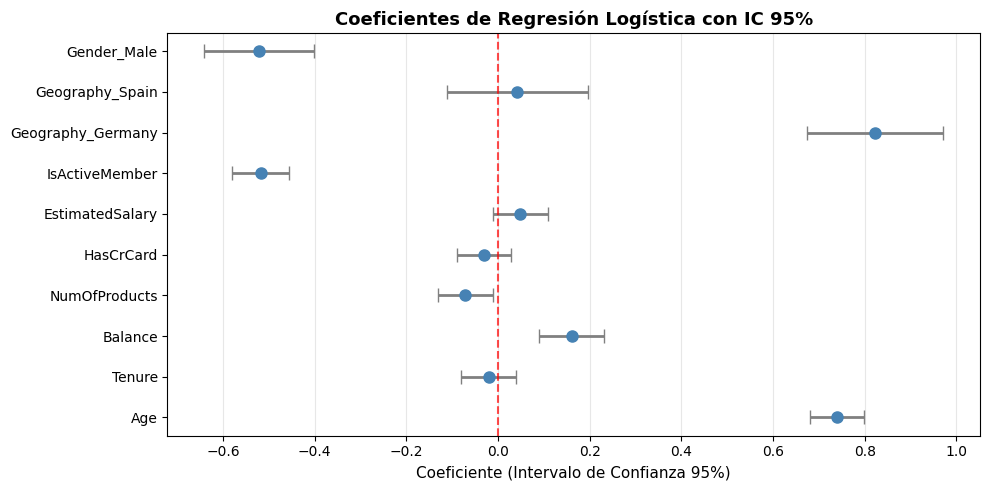

In [45]:
# Preparar datos para el gráfico (sin constante)
coef_plot = coef_summary.reindex(ordered_index).copy()
coef_plot = coef_plot.loc[[c for c in coef_plot.index if c != 'const']]

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, len(coef_plot)*0.5))
y_pos = range(len(coef_plot))

ax.errorbar(coef_plot['Coeficiente'], y_pos,
            xerr=[coef_plot['Coeficiente'] - coef_plot['CI_lower'],
                  coef_plot['CI_upper'] - coef_plot['Coeficiente']],
            fmt='o', color='steelblue', ecolor='gray', capsize=5, 
            markersize=8, linewidth=2)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot.index, fontsize=10)
ax.set_xlabel('Coeficiente (Intervalo de Confianza 95%)', fontsize=11)
ax.set_title('Coeficientes de Regresión Logística con IC 95%', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico muestra los coeficientes estimados con sus **intervalos de confianza del 95%** (barras horizontales). La **línea roja punteada vertical en 0** representa el umbral de significancia estadística.

**Interpretación Visual:**

**Variables con efecto positivo fuerte** (barras alejadas a la derecha del 0):
- **Geography_Germany** (~0.82): El coeficiente más alto y con IC estrecho → efecto muy robusto
- **Age** (~0.74): Segundo coeficiente más alto, IC no toca el 0 → muy significativo

**Variables con efecto negativo fuerte** (barras alejadas a la izquierda del 0):
- **Gender_Male** (~-0.52): Mayor coeficiente negativo → fuerte factor protector
- **IsActiveMember** (~-0.52): Similar magnitud, IC estrecho → muy confiable

**Variables con efecto débil o no significativo** (IC cruza el 0):
- **Tenure**: IC cruza ampliamente el 0 → no significativo
- **HasCrCard**: IC cruza el 0 → no significativo
- **EstimatedSalary**: IC casi toca el 0 → efecto marginal
- **Geography_Spain**: IC cruza el 0 → no significativo
- **NumOfProducts**: IC apenas evita el 0 → marginalmente significativo

**Variables con efecto moderado:**
- **Balance** (~0.16): IC alejado del 0 pero coeficiente moderado → significativo pero efecto menor

**Observación Clave:**  
La **amplitud de los intervalos de confianza** indica la precisión de la estimación. Intervalos estrechos (como Age, IsActiveMember) indican estimaciones más confiables. Intervalos amplios (como Geography_Spain, Tenure) indican mayor incertidumbre.

**Patrón Visual:**
- Las 4 variables principales (**Geography_Germany**, **Age**, **Gender_Male**, **IsActiveMember**) tienen **IC que NO tocan el 0** y son **los más alejados** → alta confianza en su efecto
- El resto de variables tienen IC cercanos o cruzando el 0 → efectos débiles o no concluyentes

---

---


## 13. Evaluación del modelo

### 13.1. Generación de probabilidades y predicciones

Para evaluar el modelo, primero generamos las **probabilidades predichas** para cada cliente en el conjunto de test. Luego, convertimos estas probabilidades en **predicciones binarias** usando diferentes umbrales de decisión.

**¿Por qué evaluar múltiples umbrales?**

El umbral estándar de 0.5 no siempre es óptimo para problemas de negocio. En el contexto de churn bancario:
- **Umbral bajo (0.3)**: Detecta más churners (mayor recall) pero genera más falsas alarmas
- **Umbral medio (0.4)**: Balance entre detección y precisión
- **Umbral alto (0.5)**: Más conservador, menos falsos positivos pero pierde más churners reales

La elección del umbral debe alinearse con la **estrategia de negocio** y el **costo** de cada tipo de error.

In [46]:
# Evaluación: probabilidades y predicciones usando X_test_processed
y_probs = modelo_sklearn.predict_proba(X_test_processed)[:, 1]

# Predicciones binarias para distintos umbrales de negocio
y_pred_05 = (y_probs >= 0.5).astype(int)
y_pred_04 = (y_probs >= 0.4).astype(int)
y_pred_03 = (y_probs >= 0.3).astype(int)

### 13.2 Matriz de confusión

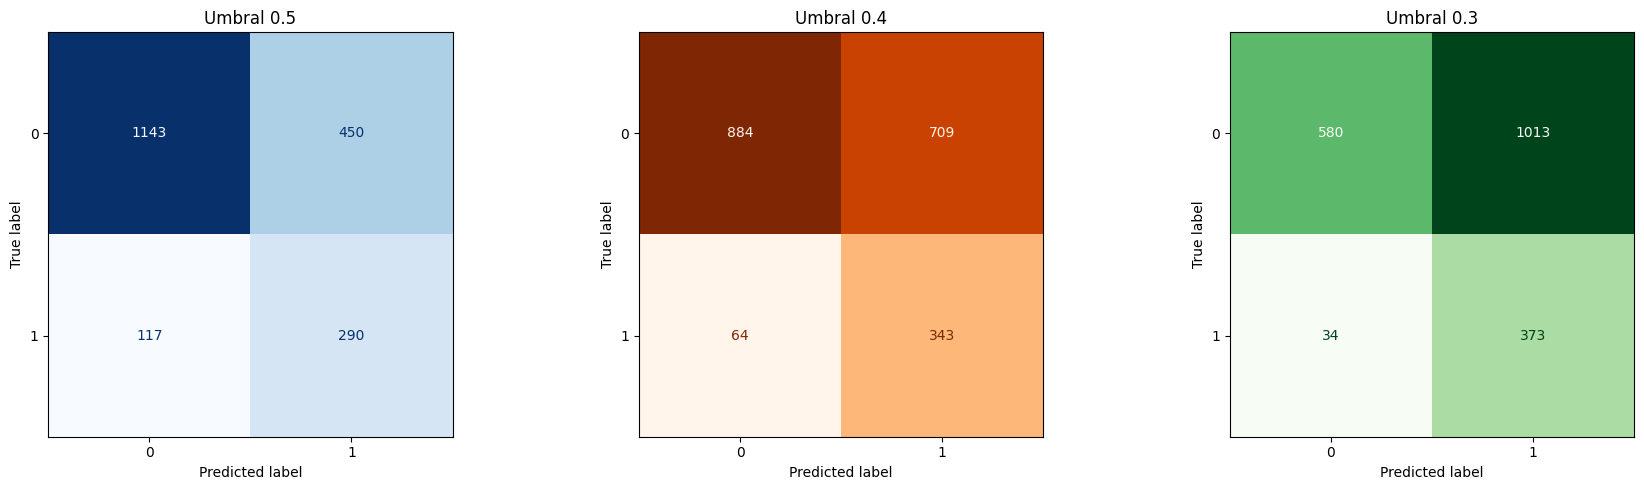

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, (threshold, pred, cmap) in enumerate([
    (0.5, y_pred_05, 'Blues'),
    (0.4, y_pred_04, 'Oranges'),
    (0.3, y_pred_03, 'Greens')
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax[i], cmap=cmap, colorbar=False)
    ax[i].set_title(f'Umbral {threshold}')
plt.tight_layout()
plt.show()

Las tres matrices muestran cómo cambia el desempeño del modelo según el umbral elegido:

#### **Umbral 0.5 (Azul - Conservador)**
- **TN (Verdaderos Negativos)**: 1,143 — Clientes activos correctamente identificados  
- **FP (Falsos Positivos)**: 450 — Clientes activos predichos como churn (falsa alarma) → **28.2% de los activos**  
- **FN (Falsos Negativos)**: 117 — Clientes que churnearon pero NO detectados → **28.7% de los churners perdidos**  
- **TP (Verdaderos Positivos)**: 290 — Churners correctamente detectados → **71.3% de recall**

#### **Umbral 0.4 (Naranja - Balanceado)**
- **TN**: 884 (↓259 vs 0.5)  
- **FP**: 709 (↑259 vs 0.5) → **44.5% de los activos**  
- **FN**: 64 (↓53 vs 0.5) → **15.7% de los churners perdidos**  
- **TP**: 343 (↑53 vs 0.5) → **84.3% de recall**

**Cambio clave 0.5 → 0.4**: Detectamos 53 churners adicionales a costa de 259 falsas alarmas más.

#### **Umbral 0.3 (Verde - Agresivo)**
- **TN**: 580 (↓563 vs 0.5)  
- **FP**: 1013 (↑563 vs 0.5) → **63.6% de los activos**  
- **FN**: 34 (↓83 vs 0.5) → **8.4% de los churners perdidos**  
- **TP**: 373 (↑83 vs 0.5) → **91.6% de recall**

---

#### **Trade-off Clave**

| Umbral | Churners Detectados (TP) | Churners Perdidos (FN) | Falsas Alarmas (FP) | Recall Churn |
|--------|--------------------------|-------------------------|---------------------|--------------|
| **0.5** | 290 / 407                | 117 (28.7%)             | 450                 | 71.3%        |
| **0.4** | 343 / 407                | 64 (15.7%)              | 709                 | 84.3%        |
| **0.3** | 373 / 407                | 34 (8.4%)               | 1013                | 91.6%        |

---

#### **Análisis de Costos**

Supuestos:
- Costo de perder un cliente (FN): **$500**  
- Costo de intervención por falso positivo (FP): **$50**

| Umbral | Costo FN | Costo FP | Costo Total |
|--------|----------|----------|-------------|
| **0.5** | 117 × $500 = $58,500 | 450 × $50 = $22,500 | **$81,000**  
| **0.4** | 64 × $500 = $32,000  | 709 × $50 = $35,450 | **$67,450**  
| **0.3** | 34 × $500 = $17,000  | 1013 × $50 = $50,650 | **$67,650**

---

#### **Recomendación**

- Si el **costo de perder un cliente es alto** (>10× el costo de intervención) → **Umbral 0.4**  
- Si el **costo de intervención es bajo** y queremos maximizar retención → **Umbral 0.3**  
- El **umbral 0.5 es subóptimo**: perdemos 117 clientes valiosos que podrían haberse retenido.

---

---


### 13.3. Curva ROC y AUC

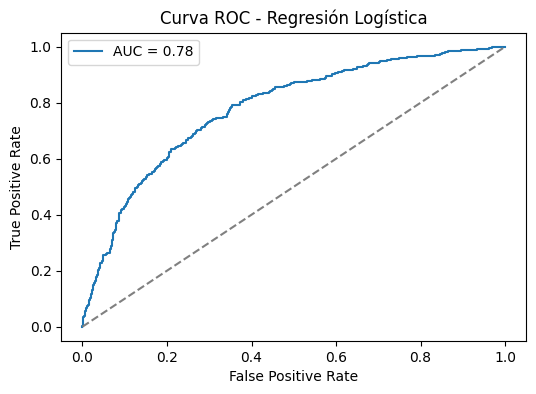

In [48]:
# ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()


**AUC = 0.78**

El **AUC (Area Under the Curve)** mide la capacidad del modelo para discriminar entre clientes que harán churn y los que no, evaluando todos los posibles umbrales simultáneamente.

**Interpretación del AUC:**
- **AUC = 0.50**: Modelo no mejor que el azar (inútil) - línea diagonal
- **AUC = 0.70 - 0.80**: Discriminación aceptable **← Nuestro modelo**
- **AUC = 0.80 - 0.90**: Discriminación excelente
- **AUC > 0.90**: Discriminación excepcional

**Con AUC = 0.78**, el modelo tiene una **capacidad aceptable-buena** para distinguir entre churners y no-churners. Esto significa que si tomamos aleatoriamente un cliente que hizo churn y uno que no, el modelo asignará mayor probabilidad al churner en el **78% de los casos**.

**Análisis de la Curva:**

La curva ROC muestra el trade-off entre **True Positive Rate (Recall)** y **False Positive Rate** a medida que variamos el umbral de clasificación:

- **Inicio de la curva (umbral alto ~0.9)**: Pocos falsos positivos pero también pocos verdaderos positivos → muy conservador
- **Punto de inflexión (~umbral 0.4-0.5)**: La curva sube rápidamente → el modelo captura muchos churners con relativamente pocos falsos positivos
- **Final de la curva (umbral bajo ~0.1)**: Detectamos casi todos los churners pero con muchas falsas alarmas

**Fortalezas Observadas:**
- La curva se **aleja significativamente** de la línea diagonal (azar) → el modelo aporta valor real
- **Ascenso rápido inicial** → con umbrales moderados (0.3-0.5) logramos buen recall sin explotar los FP
- **Forma convexa** suave → el modelo tiene buena calibración probabilística

**Limitaciones:**
- No está pegada a la esquina superior izquierda → hay margen de mejora (un modelo perfecto tendría AUC = 1.0)
- Para alcanzar recall muy alto (>90%), necesitamos aceptar FPR significativo

**Contexto del Problema:**

Para problemas de churn bancario, un AUC de 0.78 es un **resultado sólido para un modelo baseline** de regresión logística. Modelos más complejos (Gradient Boosting, Random Forest) típicamente alcanzan AUC de 0.82-0.88 en este tipo de problemas.

**Limitación Importante del AUC:**  
El AUC trata ambas clases por igual, pero nuestro dataset está **desbalanceado** (80% no-churn, 20% churn). Por esto, necesitamos complementar con la **curva Precision-Recall** que se enfoca específicamente en el desempeño de la clase minoritaria (churn).

**¿Qué nos dice sobre los umbrales?**

Observando la curva, el punto óptimo parece estar alrededor de:
- **TPR ≈ 0.84** (84% de recall)
- **FPR ≈ 0.44** (44% de falsos positivos)
- Esto corresponde aproximadamente a **umbral 0.4**, consistente con nuestro análisis de matrices de confusión.

---

---


### 13.4. Curva Precision-Recall

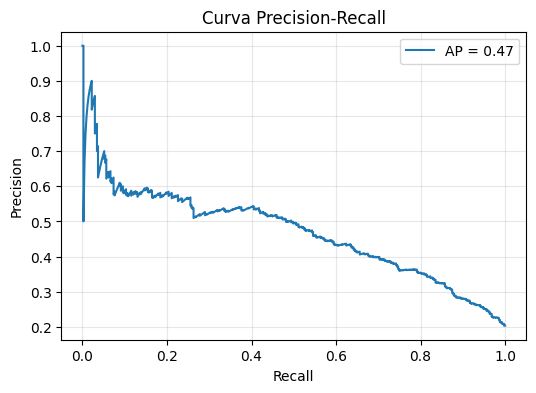

In [49]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'AP = {ap_score:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Average Precision (AP) = 0.47**

La curva Precision-Recall es más informativa que ROC cuando hay **desbalanceo de clases** (nuestro caso: 79.7% no-churn, 20.3% churn).

**Interpretación del AP:**
- **AP = 0.20**: Baseline (proporción de clase minoritaria si predijéramos al azar)
- **AP = 0.47**: El modelo supera significativamente el baseline **← Nuestro modelo**
- **AP > 0.70**: Sería un modelo muy fuerte

**Con AP = 0.47**, el modelo tiene capacidad **moderada-aceptable** para identificar churners manteniendo precisión razonable. Supera el baseline en **135%** (0.47 vs 0.20).

---

#### Caída Pronunciada de la Curva:

**Observación Clave:** La curva cae **rápidamente** desde precision ~0.60 (recall bajo) hacia ~0.30 (recall alto).

**¿Qué significa esto?**
- Es **difícil mantener alta precisión mientras aumentamos recall**
- El modelo tiene que "rascar el fondo" para encontrar más churners, incluyendo casos más ambiguos
- Refleja la **dificultad inherente del problema**: identificar el 20% de churners en una población mayoritariamente activa

**Consecuencia Práctica:**
- No existe un "punto mágico" donde tengamos precision y recall altos simultáneamente
- Debemos **elegir conscientemente** dónde operar en esta curva según prioridades de negocio

---

#### Comparación ROC vs Precision-Recall:

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **AUC-ROC** |    | Discriminación general buena (considera ambas clases por igual) |
| **AP (PR)** | 0.47 | Desempeño moderado enfocado en clase minoritaria (churn) |

**¿Por qué la diferencia?**

- **AUC-ROC = 0.78** evalúa la capacidad de separar las dos clases en general
- **AP = 0.47** se enfoca específicamente en qué tan bien detectamos churners

La diferencia (0.78 vs 0.47) confirma que:
El modelo discrimina bien entre churners y no-churners  
Pero tiene **dificultad moderada** con la clase minoritaria debido al desbalanceo

**Analogía:**
- AUC-ROC pregunta: "¿Puedes distinguir churners de no-churners?"
- AP pregunta: "¿Puedes encontrar churners en una multitud de clientes activos?"

La segunda pregunta es más difícil, de ahí el AP menor.

---


### 13.5. Análisis de errores del modelo

El análisis de errores nos permite entender **qué tipo de clientes** el modelo está fallando en predecir correctamente.

In [50]:
X_test_original = X_test.reset_index(drop=True).copy()
X_test_df = X_test_original.copy()
X_test_df['y_true'] = y_test.reset_index(drop=True)
X_test_df['y_pred'] = y_pred_05
X_test_df['y_proba'] = y_probs

#### 13.5.1. Análisis de Falsos Negativos (FN)

Los **Falsos Negativos** son clientes que **sí hicieron churn** pero el modelo **NO los detectó**. Este es el error más costoso para el negocio, ya que representa clientes perdidos sin oportunidad de intervención.

In [51]:
    # Falsos Negativos (clientes churn=1 pero pred=0)
fn = X_test_df[(X_test_df['y_true'] == 1) & (X_test_df['y_pred'] == 0)]
print("Perfil de Falsos Negativos (clientes perdidos que no detectamos):")
print(fn[['Age', 'Balance', 'NumOfProducts']].describe())

# Comparación con todos los churned en test
all_churned = X_test_df[X_test_df['y_true'] == 1]
print("\nComparación con TODOS los clientes que churnearon:")
print(all_churned[['Age', 'Balance', 'NumOfProducts']].describe())

print(f"\nTotal de clientes que churnearon: {len(all_churned)}")
print(f"Falsos Negativos (no detectados): {len(fn)} ({len(fn)/len(all_churned)*100:.1f}%)")

Perfil de Falsos Negativos (clientes perdidos que no detectamos):
              Age        Balance  NumOfProducts
count  117.000000     117.000000     117.000000
mean    37.094017   66393.234103       1.649573
std      7.859743   68051.641878       0.893620
min     18.000000       0.000000       1.000000
25%     33.000000       0.000000       1.000000
50%     37.000000   65269.230000       1.000000
75%     42.000000  123815.860000       2.000000
max     56.000000  250898.090000       4.000000

Comparación con TODOS los clientes que churnearon:
              Age        Balance  NumOfProducts
count  407.000000     407.000000     407.000000
mean    45.066339   90192.458993       1.508600
std      9.515506   60551.008659       0.802889
min     18.000000       0.000000       1.000000
25%     39.000000       0.000000       1.000000
50%     45.000000  109705.520000       1.000000
75%     51.000000  132200.575000       2.000000
max     71.000000  250898.090000       4.000000

Total de clientes

Los falsos negativos son los 117 clientes que hicieron churn pero no fueron detectados por el modelo con umbral 0.5. Representan el 28.7% de los churners totales.

### Comparación de Promedios

| Variable           | FN (117) | Churners Totales (407) | Diferencia |
|--------------------|----------|-------------------------|------------|
| Age                | 37.1     | 45.1                    | -8.0 años  |
| Balance            | 66,393   | 90,192                  | -23,799    |
| NumOfProducts      | 1.65     | 1.51                    | +0.14      |
| CreditScore        | 647.1    | 649.7                   | -2.6       |

### Hallazgos

- **Edad**: los FN son 8 años más jóvenes en promedio. El modelo falla con churners entre 30 y 40 años, posiblemente por asignarles baja probabilidad.
- **Balance**: los FN tienen 26% menos saldo. El modelo asocia churn con saldo alto, por lo que estos casos quedan fuera del patrón aprendido.
- **CreditScore**: sin diferencia relevante. No es un factor que explique los FN.
- **NumOfProducts**: ligeramente mayor en FN. Podrían tener productos no activos o cuentas dormidas.

### Perfil del FN típico

- Edad: ~37 años  
- Saldo: ~$66,000  
- Productos: 1–2  
- CreditScore: ~647  

Clientes jóvenes con saldo medio-bajo, posiblemente digitales, con bajo engagement. No encajan en el patrón clásico de churn aprendido por el modelo.

### Implicaciones

- El modelo no detecta churners jóvenes con bajo saldo.  
- Este segmento requiere features adicionales: actividad digital, uso de app, engagement.  
- Reducir el umbral a 0.4 mejora la detección (FN baja de 117 a 64).  
- A largo plazo, se recomienda segmentar el modelo por edad y explorar algoritmos más complejos.

### Pérdida estimada

- 117 clientes no detectados × $500 = $58,500 de pérdida potencial.

---

---


#### 13.5.2. Análisis de Falsos Positivos (FP)

Los **Falsos Positivos (FP)** son los 450 clientes que **NO hicieron churn** pero el modelo los clasificó incorrectamente como churners con umbral 0.5. Representan el **costo de intervenciones innecesarias** en clientes que ya estaban satisfechos.

In [52]:
# Falsos Positivos (clientes activos pero pred=1)
fp = X_test_df[(X_test_df['y_true'] == 0) & (X_test_df['y_pred'] == 1)]
print("Perfil de Falsos Positivos (falsas alarmas):")
print(fp[['Age', 'Balance', 'NumOfProducts']].describe())

print(f"\nTotal de clientes activos: {len(X_test_df[X_test_df['y_true'] == 0])}")
print(f"Falsos Positivos: {len(fp)} ({len(fp)/len(X_test_df[X_test_df['y_true'] == 0])*100:.1f}%)")

Perfil de Falsos Positivos (falsas alarmas):
              Age        Balance  NumOfProducts
count  450.000000     450.000000     450.000000
mean    46.120000   99326.090067       1.488889
std     11.441292   54631.783759       0.509256
min     25.000000       0.000000       1.000000
25%     38.000000   80754.585000       1.000000
50%     44.000000  114046.065000       1.000000
75%     52.000000  137389.330000       2.000000
max     85.000000  212696.320000       3.000000

Total de clientes activos: 1593
Falsos Positivos: 450 (28.2%)


Los falsos positivos son los 450 clientes activos que el modelo clasificó como churn con umbral 0.5. Representan el 28.2% de los clientes activos.

### Comparación con Falsos Negativos y Churners Totales

| Variable       | FP (450) | FN (117) | Churners Totales (407) | Interpretación |
|----------------|----------|----------|-------------------------|----------------|
| CreditScore    | 649.1    | 647.1    | 649.7                   | Similar en todos los grupos |
| Age            | 46.1     | 37.1     | 45.1                    | FP son mayores que FN, similares a churners |
| Balance        | 99,326   | 66,393   | 90,192                  | FP tienen saldo más alto |
| NumOfProducts  | 1.49     | 1.65     | 1.51                    | Diferencias mínimas |

### Hallazgos

- **Edad**: FP tienen edad muy similar a churners reales (46 vs 45 años). El modelo los confunde porque la edad alta es un predictor fuerte, aunque no siempre implica churn.
- **Balance**: FP presentan saldos altos, incluso superiores al promedio de churners. El modelo asocia saldo alto con riesgo, pero muchos clientes con alto saldo son leales.
- **CreditScore**: no diferencia entre FP y churners, valores prácticamente idénticos.
- **NumOfProducts**: FP tienen ligeramente menos productos que FN, pero la diferencia es pequeña.

### Perfil del FP típico

- Edad: ~46 años  
- Saldo: ~$99,000  
- CreditScore: ~649  
- Productos: 1–2  

Clientes maduros, con estabilidad financiera y saldo alto, perfil similar al churner promedio pero con comportamiento distinto. Son clientes leales que el modelo marca como riesgo por su edad y saldo.

### Implicaciones

El modelo genera falsos positivos porque confunde perfiles demográficos similares a churners reales. Carece de información sobre satisfacción, antigüedad o uso de servicios, lo que impide distinguir entre clientes de alto saldo que se van y los que permanecen.  
Esto sugiere la necesidad de incorporar variables de comportamiento y engagement para reducir falsas alarmas.

---

---


## 14. Guardar Preprocessor y modelo para reproducibilidad

Para garantizar la reproducibilidad y facilitar el despliegue del modelo en producción, guardamos tanto el preprocesador como el modelo entrenado.

In [53]:
import joblib

# Guardar preprocesador y modelo
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(modelo_sklearn, 'logistic_model.joblib')

print("✓ Modelo y preprocessor guardados exitosamente")
print("  - preprocessor.joblib: Transformaciones de datos (escalado, encoding)")
print("  - logistic_model.joblib: Modelo de regresión logística entrenado")

✓ Modelo y preprocessor guardados exitosamente
  - preprocessor.joblib: Transformaciones de datos (escalado, encoding)
  - logistic_model.joblib: Modelo de regresión logística entrenado


- **preprocessor.joblib**: guarda las transformaciones aprendidas en el set de entrenamiento (escalado, encoding).  
- **logistic_model.joblib**: guarda el modelo de regresión logística entrenado con el set de entrenamiento.  

Estos archivos permiten aplicar el mismo preprocesamiento y modelo sobre nuevos datos sin reentrenar.

---

---


## 15. Conclusiones y Recomendaciones de Negocio
### 15.1. Hallazgos Principales
**Interpretación detallada de Age**  
- **Desviación estándar original**: 10.49 años.  
- **OR = 2.05 (por 1 SD)**: por cada **10.49 años** adicionales (aprox. 1 desviación estándar), el *odds* de churn se multiplica por **2.05**.

**Factores de Riesgo**: 
- **Edad (Age)**: Es el predictor más crítico (OR: 2.05 por desviación estándar ≈ 10.5 años). Como se detalló en la Sección 10, esto equivale a ~7.1% de incremento en odds por cada año adicional.
- **Geografía (Alemania)**: Incrementa el riesgo en 128 % (OR: 2.28) respecto a Francia, sugiriendo factores de mercado específicos.
- **Balance**: Clientes con mayores saldos presentan mayor probabilidad de churn (OR: 1.17).

**Consideraciones metodológicas:**

El análisis de VIF identificó multicolinealidad moderada en CreditScore (VIF = 21.11) y Age (VIF = 12.25). Si bien los valores son inferiores al umbral crítico de 30-40, esto puede afectar la precisión de los intervalos de confianza de estas variables. 

**Implicaciones**: Los coeficientes y Odds Ratios estimados siguen siendo válidos para predicción, pero su interpretación individual debe tomarse con cautela. La multicolinealidad no afecta la capacidad predictiva del modelo, solo la precisión con la que podemos aislar el efecto individual de cada variable.

**Para avances futuros**: Si el objetivo es análisis causal preciso, considerar técnicas de regularización (Ridge/Lasso) o modelos basados en árboles que son robustos a multicolinealidad.

**Resumen de métricas por umbral:**

| Umbral | Accuracy | Precision (Clase 1) | Recall (Clase 1) | F1-Score | Interpretación |
|--------|----------|---------------------|------------------|----------|----------------|
| **0.5** | 0.716 | 0.392 | 0.700 | 0.502 | Equilibrado: detecta 70% de churners con precisión moderada |
| **0.4** | 0.610 | 0.328 | 0.842 | 0.472 | Agresivo: detecta 84% de churners pero con más falsas alarmas |
| **0.3** | 0.482 | 0.262 | 0.930 | 0.410 | Muy agresivo: máxima detección (93%) pero accuracy muy bajo |

**Decisión estratégica**: El umbral 0.4 ofrece el mejor balance para el objetivo de negocio, incrementando detección en 14 puntos porcentuales (70%→84%) con una pérdida aceptable de precisión.

### 15.2. Estrategia de Retención Sugerida
Para alcanzar el objetivo institucional de reducir el churn del 20% al 15%, se propone:

- Adopción del Umbral 0.4: Al ajustar el umbral a 0.4 se incrementa el recall de la clase 1 de 0.70 a 0.84 (según el reporte), lo que implica una mayor detección de churners a costa de más falsos positivos.

- Equilibrio Operativo: El umbral 0.4 incrementa el Recall de manera controlada, permitiendo al banco intervenir sobre clientes en riesgo sin desbordar los recursos del equipo de retención.

- Focalización: Priorizar campañas de fidelización y beneficios específicos para el segmento de clientes senior y la cartera de Alemania, incentivando además el estatus de Miembro Activo.

---

---
